
# 🌌 SpecCLIP Demo

**Authors:** Xiaosheng Zhao (JHU)

This notebook demonstrates how to:
1. Load the pretrained **SpecCLIP** model and all downstream-models from Hugging Face  
2. Predict stellar parameters from an input spectrum  
3. Retrieve similar stars using a precomputed embedding index
4. Predict cross-modal spectra given a query spectra

> 🧭 **Paper:** [SpecCLIP: Aligning and Translating Spectroscopic Measurements for Stars](https://arxiv.org/abs/2507.01939)


For debugging:

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import torch

if torch.cuda.is_available():
    print("GPU is available.")
    # You can also get the name of the GPU
    print(f"GPU Name: {torch.cuda.get_device_name(0)}") 
else:
    print("No GPU available. PyTorch will run on CPU.")

GPU is available.
GPU Name: Tesla V100-SXM2-16GB


### Download Models at once

**First set the path of LOCAL_MODEL_DIR in download_and_setup.py to download models and/or test data**

In [ ]:
# Step 1: Install required packages
#!pip install -q huggingface_hub

# Step 2: Authenticate with HuggingFace
from huggingface_hub import login
import os

print("=" * 70)
print("HuggingFace Authentication")
print("=" * 70)
print("\nTo download the models, you need a HuggingFace token.")
print("Get your token from: https://huggingface.co/settings/tokens")
print("\nMake sure to select 'Read' permission when creating the token.")
print("=" * 70)

# Option 1: Interactive login (will prompt for token)
try:
    #login()
    #Login with token directly
    login(token="YOUR TOKEN")
    print("\n✓ Authentication successful!")
except Exception as e:
    print(f"\n✗ Authentication failed: {e}")
    print("\nAlternatively, you can:")
    print("  1. Run in terminal: huggingface-cli login")
    print("  2. Or set token: login(token='hf_your_token_here')")

# Step 3: Download models
print("\n" + "=" * 70)
print("Downloading Models and/or Test Data")
print("=" * 70)
# Option A: Full download (models + test data) for retrieval tasks
#!python download_and_setup.py --include-test-data

# Option B: Models only (faster, for parameter estimation only)
!python download_and_setup.py

# Option C: Test data only (if you already downloaded models)
# !python download_and_setup.py --test-data-only

print("\n✓ Setup complete! You can now use the models and test data.")

## 🔮 Predict Stellar Parameters

* **For LAMOST LRS**, the predicted parameters include:

  * **Chemical abundances (12):**
    [α/Fe], [C/Fe], [N/Fe], [Mg/Fe], [O/Fe], [Al/Fe], [Si/Fe], [Ca/Fe], [Ti/Fe], [Mn/Fe], [Ni/Fe], [Cr/Fe]
  * **Asteroseismic parameters:**
    Δν, ν_max, mass, radius, age, ΔΠ₁ 
  * **Atmospheric parameters:**
    T_eff, log g, [Fe/H] 
  * **Other parameters:**
    RV, E(BP–RP)

* **For Gaia XP**, the predicted parameters include:

  * **Chemical abundances:** [α/Fe], [C/Fe], [N/Fe]
  * **Atmospheric parameters:** T_eff, log g, [Fe/H] 
  * **Extinction:** E(BP–RP)

For these different parameters, here as an example, we adopt the following strategies regarding the **foundation model** (SpecCLIP-pr or SpecCLIP-split, used to output the embeddings) and the **downstream model** (MLP or SBI, using nsf or maf) choices. These choices are roughly guided by the testing performance as indicated in Table 1 from the paper [SpecCLIP: Aligning and Translating Spectroscopic Measurements for Stars](https://arxiv.org/abs/2507.01939)

* **SpecCLIP-pr**
    * **LAMOST LRS:**
      Chemical abundances (MLP), Asteroseismic parameters (SBI-maf), E(BP–RP) (MLP)
    * **Gaia XP:**
      Chemical abundances (MLP), Extinction (MLP), [Fe/H] (MLP)
* **SpecCLIP-split**
    * **LAMOST LRS:**
      T_eff (SBI-nsf), log g (SBI-maf), RV (SBI-maf), [Fe/H] (MLP)
    * **Gaia XP:**
      T_eff (SBI-nsf), log g (SBI-maf)

* **Note**: The posterior results (median + error) from SBI are not generated with a fixed sampling seed, so the numbers may vary from one run to another.
---

### Configuration After Download

In [21]:
import json
from stellar_params_unified import UnifiedStellarParameterPredictor, get_default_config
from spectral_retrieval import SpectralRetriever

# For parameter estimation
with open('config_lrs.json', 'r') as f:
    lrs_config = json.load(f)
    #lrs_config = get_default_config('LAMOST_LRS')

with open('config_xp.json', 'r') as f:
    xp_config = json.load(f)
    #xp_config = get_default_config('GAIA_XP')

#predictor = UnifiedStellarParameterPredictor('LAMOST_LRS', lrs_config=lrs_config)

# For retrieval
#with open('config_retrieval.json', 'r') as f:
#    retrieval_config = json.load(f)

#retriever = SpectralRetriever(**retrieval_config)

### Basic Setup and Imports

In [4]:
# For display
from IPython.display import display
import pandas as pd

### Initialize for LAMOST LRS

In [112]:
# Initialize predictor for LAMOST LRS spectra
predictor_lrs = UnifiedStellarParameterPredictor(survey_type='LAMOST_LRS', lrs_config=lrs_config)

# Check what parameters are available
print(f"Available parameters: {predictor_lrs.get_available_parameters()}")
print(f"\nWavelength range: {predictor_lrs.wavelength_range}")

Initializing LAMOST LRS predictor...
This predictor supports:
  - Chemical abundances (12 elements)
  - Asteroseismic parameters
  - Radial velocity
  - Atmospheric parameters
  - Reddening
Using device: cuda
Loading models...
Total trainable parameters: 42,846,129
Total trainable parameters: 42,846,129
Models loaded successfully!
Available parameters: ['chemical', 'seismic', 'RV', 'DPi1', 'atmospheric', 'ebprp']

Wavelength range: 4000-5600 Å


### Predict All Parameters from LAMOST LRS

In [57]:
# Predict all parameters with nice formatting
results_lrs_all = predictor_lrs.predict(
    './test_data/lrs/spec-55859-F5902_sp02-084.fits.gz', #sample1_matrix.fits, sample4_txt.csv
    parameter_types=['all'],
    simple_header=False,
    display_format='row'
)

# Display with formatted style
display(predictor_lrs.display_results(results_lrs_all, style='formatted'))

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

,Parameter,Prediction,Error,Method
0,[α/Fe],0.16,-,MLP
1,[C/Fe],0.15,-,MLP
2,[N/Fe],0.84,-,MLP
3,[Mg/Fe],0.25,-,MLP
4,[O/Fe],0.27,-,MLP
5,[Al/Fe],0.10,-,MLP
6,[Si/Fe],0.15,-,MLP
7,[Ca/Fe],0.08,-,MLP
8,[Ti/Fe],-0.07,-,MLP
9,[Mn/Fe],-0.20,-,MLP


### Predict Specific Parameters (LAMOST)

In [58]:
# Predict only atmospheric parameters
results_lrs_atm = predictor_lrs.predict(
    './test_data/lrs/spec-55859-F5902_sp02-084.fits.gz',
    parameter_types=['atmospheric'],
    simple_header=True
)

display(results_lrs_atm)

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

,Parameter,Prediction,Error,Method
0,teff,5892.63,93.47,SBI
1,logg,4.11,0.09,SBI
2,fe_h,-0.91,NaN,MLP


### Predict Multiple Parameters (LAMOST)

In [59]:
# Predict chemical abundances and atmospheric parameters
results_lrs_multi = predictor_lrs.predict(
    './test_data/lrs/spec-55859-F5902_sp02-084.fits.gz',
    parameter_types=['chemical', 'atmospheric'],
    simple_header=False
)

# Highlight by method
display(predictor_lrs.display_results(results_lrs_multi, style='highlight'))

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

,Parameter,Prediction,Error,Method
0,[α/Fe],0.16,nan,MLP
1,[C/Fe],0.15,nan,MLP
2,[N/Fe],0.84,nan,MLP
3,[Mg/Fe],0.25,nan,MLP
4,[O/Fe],0.27,nan,MLP
5,[Al/Fe],0.10,nan,MLP
6,[Si/Fe],0.15,nan,MLP
7,[Ca/Fe],0.08,nan,MLP
8,[Ti/Fe],-0.07,nan,MLP
9,[Mn/Fe],-0.20,nan,MLP


### Switch to Gaia XP

In [117]:
# Switch to Gaia XP predictor
predictor_lrs.switch_survey('Gaia_XP',config=xp_config)

# Or create a new one
# predictor_xp = UnifiedStellarParameterPredictor(survey_type='Gaia_XP')


Switching from LAMOST_LRS to GAIA_XP...
Initializing Gaia XP predictor...
This predictor supports:
  - Alpha element abundance
  - Carbon and Nitrogen abundances
  - Atmospheric parameters
  - Reddening
Using device: cuda
Loading models...
Total trainable parameters: 42,846,129
Total trainable parameters: 42,846,129
Total trainable parameters: 42,846,129
Models loaded successfully!
Switch complete!


Models loaded successfully!
Switch complete!


### Predict from Gaia XP Spectrum

In [118]:
# Predict all parameters from Gaia XP
results_xp = predictor_lrs.predict(
    './test_data/xp/sample4_txt_xp.csv',
    parameter_types=['all'],
    simple_header=False
)

display(predictor_lrs.display_results(results_xp, style='formatted'))

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

,Parameter,Prediction,Error,Method
0,[α/Fe],0.13,nan,MLP
1,[C/Fe],-0.05,nan,MLP
2,[N/Fe],0.25,nan,MLP
3,T_eff [K],4571.51,299.66,SBI
4,log g [cgs],1.98,0.19,SBI
5,[Fe/H] [dex],-0.51,nan,MLP
6,E(BP-RP) [mag],0.49,nan,MLP


### Batch Processing

In [61]:
# Process multiple LAMOST spectra
file_list = [
    './test_data/lrs/spec-55859-F5902_sp02-084.fits.gz',
    './test_data/lrs/sample1_matrix.fits',
]

# Reinitialize for LAMOST if needed
predictor_lrs = UnifiedStellarParameterPredictor('LAMOST_LRS', lrs_config=lrs_config)

# Batch predict
batch_results = predictor_lrs.predict_batch(
    file_list,
    parameter_types=['atmospheric'],
    simple_header=True
)

# Display each result
for i, result in enumerate(batch_results):
    if result is not None:
        print(f"\n--- Spectrum {i+1} ---")
        display(result)

Initializing LAMOST LRS predictor...
This predictor supports:
  - Chemical abundances (12 elements)
  - Asteroseismic parameters
  - Radial velocity
  - Atmospheric parameters
  - Reddening
Using device: cuda
Loading models...
Total trainable parameters: 42,846,129
Total trainable parameters: 42,846,129
Models loaded successfully!
Processing 1/2: ./test_data/lrs/spec-55859-F5902_sp02-084.fits.gz


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

Processing 2/2: ./test_data/lrs/sample1_matrix.fits


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]


--- Spectrum 1 ---


,Parameter,Prediction,Error,Method
0,teff,5894.64,82.82,SBI
1,logg,4.11,0.09,SBI
2,fe_h,-0.91,NaN,MLP



--- Spectrum 2 ---


,Parameter,Prediction,Error,Method
0,teff,4995.72,491.97,SBI
1,logg,3.82,0.38,SBI
2,fe_h,-0.40,NaN,MLP


### Compare LRS vs XP for Same Star

Get the example star with paired spectra

In [27]:
import h5py
h5_data_path = '/home/idies/workspace/Temporary/xzhao/scratch/pretrained_models/test_data/gaia_lamost_test_only.h5'
with h5py.File(h5_data_path, 'r') as f:
    source_ids = np.array(f['test/source_ids'][:])
    gaia_spectra = np.array(f['test/gaia_spectra'][:])
    lamost_spectra = np.array(f['test/lamost_spectra'][:])

# Randomly choose a star index
star_index = 72 

w_start = 3.602
w_end = w_start + 1e-4 * 1461
new_log_wave = np.linspace(w_start, w_end, 1462)

wavelength = 10 ** new_log_wave
flux = lamost_spectra[star_index ][...,0] 

wavelength_xp = np.arange(336, 1021, 2) 
flux_xp = gaia_spectra[star_index ][...,0]

# Save spectrum to temp file for prediction
import tempfile
with tempfile.NamedTemporaryFile(mode='w', suffix='.csv', delete=False) as f:
    for w, f_val in zip(wavelength, flux):
        f.write(f"{w},{f_val}\n")
    temp_path = f.name

with tempfile.NamedTemporaryFile(mode='w', suffix='.csv', delete=False) as f:
    for w, f_val in zip(wavelength_xp, flux_xp):
        f.write(f"{w},{f_val}\n")
    temp_path_xp = f.name

Do the comparison

In [28]:
from stellar_params_unified import compare_surveys

# Compare predictions from both surveys
comparison = compare_surveys(
    lrs_spectrum_path=temp_path,
    xp_spectrum_path=temp_path_xp,
    parameter_types='atmospheric',
    simple_header=False,
    lrs_config=lrs_config,
    xp_config=xp_config
)

print("LAMOST LRS Results:")
display(comparison['lrs_results'])

print("\nGaia XP Results:")
display(comparison['xp_results'])

Predicting from LAMOST LRS spectrum...
Initializing LAMOST LRS predictor...
This predictor supports:
  - Chemical abundances (12 elements)
  - Asteroseismic parameters
  - Radial velocity
  - Atmospheric parameters
  - Reddening
Using device: cuda
Loading models...
Total trainable parameters: 42,846,129
Total trainable parameters: 42,846,129
Models loaded successfully!


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]


Predicting from Gaia XP spectrum...
Initializing Gaia XP predictor...
This predictor supports:
  - Alpha element abundance
  - Carbon and Nitrogen abundances
  - Atmospheric parameters
  - Reddening
Using device: cuda
Loading models...
Total trainable parameters: 42,846,129
Total trainable parameters: 42,846,129
Total trainable parameters: 42,846,129
Models loaded successfully!


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

LAMOST LRS Results:


,Parameter,Prediction,Error,Method
0,T_eff [K],4435.31,119.80,SBI
1,log g [cgs],4.58,0.06,SBI
2,[Fe/H] [dex],0.09,NaN,MLP



Gaia XP Results:


,Parameter,Prediction,Error,Method
0,T_eff [K],4311.60,260.65,SBI
1,log g [cgs],4.58,0.08,SBI
2,[Fe/H] [dex],0.25,NaN,MLP


### Quick predictions (Convenience Functions)

In [62]:
from stellar_params_unified import predict_from_lamost, predict_from_gaia

# Quick LAMOST prediction
lrs_quick = predict_from_lamost(
    './test_data/lrs/spec-55859-F5902_sp02-084.fits.gz',
    parameter_types=['atmospheric', 'RV'],
    lrs_config=lrs_config
)
display(lrs_quick)

# Quick Gaia XP prediction
xp_quick = predict_from_gaia(
    './test_data/xp/sample4_txt_xp.csv',
    parameter_types=['atmospheric'],
    xp_config=xp_config
)
display(xp_quick)

Initializing LAMOST LRS predictor...
This predictor supports:
  - Chemical abundances (12 elements)
  - Asteroseismic parameters
  - Radial velocity
  - Atmospheric parameters
  - Reddening
Using device: cuda
Loading models...
Total trainable parameters: 42,846,129
Total trainable parameters: 42,846,129
Models loaded successfully!


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

,Parameter,Prediction,Error,Method
0,rv,3.26,5.95,SBI
1,teff,5892.23,102.41,SBI
2,logg,4.11,0.09,SBI
3,fe_h,-0.91,NaN,MLP


Initializing Gaia XP predictor...
This predictor supports:
  - Alpha element abundance
  - Carbon and Nitrogen abundances
  - Atmospheric parameters
  - Reddening
Using device: cuda
Loading models...
Total trainable parameters: 42,846,129
Total trainable parameters: 42,846,129
Total trainable parameters: 42,846,129
Models loaded successfully!


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

,Parameter,Prediction,Error,Method
0,teff,4571.75,278.01,SBI
1,logg,1.98,0.19,SBI
2,fe_h,-0.51,NaN,MLP


### Cunstom Configuration

In [ ]:
# Modify paths if needed
config['spectrum_encoder_path'] = '/your/encoder/path'
config['mlp_model_path_feh'] = '/your/feh/model/path'

# Initialize with custom config
predictor_custom = UnifiedStellarParameterPredictor(
    survey_type='LAMOST_LRS',
    lrs_config=lrs_config
)

### Get Predictor Information

In [122]:
# Get information about current predictor
info = predictor_lrs.get_info()

print(f"Survey Type: {info['survey_type']}")
print(f"Wavelength Range: {info['wavelength_range']}")
print(f"Available Parameters: {info['available_parameters']}")
print(f"Supported Formats: {info['supported_formats']}")

Survey Type: LAMOST_LRS
Wavelength Range: 4000-5600 Å
Available Parameters: ['chemical', 'seismic', 'RV', 'DPi1', 'atmospheric', 'ebprp']
Supported Formats: ['.fits', '.fit', '.csv', '.txt']


### Export Results

In [123]:
# Save results to CSV
results_lrs_all.to_csv('stellar_parameters_lrs.csv', index=False)

# Save to Excel
#results_lrs_all.to_excel('stellar_parameters_lrs.xlsx', index=False)

# Or save as markdown table
with open('results.md', 'w') as f:
    f.write(results_lrs_all.to_markdown())

### Common use Cases

#### Quick Atmospheric Parameters

In [64]:
predictor = UnifiedStellarParameterPredictor('LAMOST_LRS', lrs_config=lrs_config)
results = predictor.predict('./test_data/lrs/spec-55859-F5902_sp02-084.fits.gz', parameter_types=['atmospheric'])
display(results)

Initializing LAMOST LRS predictor...
This predictor supports:
  - Chemical abundances (12 elements)
  - Asteroseismic parameters
  - Radial velocity
  - Atmospheric parameters
  - Reddening
Using device: cuda
Loading models...
Total trainable parameters: 42,846,129
Total trainable parameters: 42,846,129
Models loaded successfully!


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

,Parameter,Prediction,Error,Method
0,teff,5890.52,97.39,SBI
1,logg,4.11,0.09,SBI
2,fe_h,-0.91,NaN,MLP


### Full Chemical Analysis

In [66]:
predictor = UnifiedStellarParameterPredictor('LAMOST_LRS', lrs_config=lrs_config)
results = predictor.predict('./test_data/lrs/spec-55859-F5902_sp02-084.fits.gz', parameter_types=['chemical', 'atmospheric'])
display(predictor.display_results(results, style='formatted'))

Initializing LAMOST LRS predictor...
This predictor supports:
  - Chemical abundances (12 elements)
  - Asteroseismic parameters
  - Radial velocity
  - Atmospheric parameters
  - Reddening
Using device: cuda
Loading models...
Total trainable parameters: 42,846,129
Total trainable parameters: 42,846,129
Models loaded successfully!


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

,Parameter,Prediction,Error,Method
0,a_fe,0.16,-,MLP
1,c_fe,0.15,-,MLP
2,n_fe,0.84,-,MLP
3,mg_fe,0.25,-,MLP
4,o_fe,0.27,-,MLP
5,al_fe,0.10,-,MLP
6,si_fe,0.15,-,MLP
7,ca_fe,0.08,-,MLP
8,ti_fe,-0.07,-,MLP
9,mn_fe,-0.20,-,MLP


#### Catalog Processing (To Be Refined)

In [68]:
import glob

predictor = UnifiedStellarParameterPredictor('LAMOST_LRS', lrs_config=lrs_config)
spectra = glob.glob('./test_data/lrs/spec-*')

all_results = []
for spec in spectra:
    result = predictor.predict(spec, parameter_types=['atmospheric'])
    all_results.append(result)

# Combine all results
combined_df = pd.concat(all_results, ignore_index=True)
combined_df.to_csv('catalog_results.csv', index=False)

Initializing LAMOST LRS predictor...
This predictor supports:
  - Chemical abundances (12 elements)
  - Asteroseismic parameters
  - Radial velocity
  - Atmospheric parameters
  - Reddening
Using device: cuda
Loading models...
Total trainable parameters: 42,846,129
Total trainable parameters: 42,846,129
Models loaded successfully!


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

## 🔍 Similar-Star Retrieval & Cross-Modal Predictions (embeddings)
Spectral Retrieval and Cross-Modal Analysis

### Summary of All Tasks

| Task |  Description |
|------|-------------|
| 1 | Build embedding database from test set |
| 2 | In-modal retrieval from test set (verify top-1 is self) |
| 3 | In-modal retrieval with external spectra |
| 4 | Cross-modal retrieval from test set (verify top-1 is paired) |
| 5 | Cross-modal retrieval with external spectra |
| 6 | Cross-modal prediction for test and external spectra |

* **Note:** Since the LAMOST LRS (continuum-normalized) and Gaia XP (550nm flux-normalized) are not normalized in the same way, even the comparison between the two for the same star may 'look' different.
---

### Setup and Imports

In [127]:
import numpy as np
import matplotlib.pyplot as plt
import json
from spectral_retrieval import SpectralRetriever, get_default_model_paths

# For loading external spectra (reuse from stellar parameter prediction)
import sys
sys.path.append('/home/idies/workspace/Storage/xzhao/DESI-workspace/xzhao/SpecCLIP/Downstream-with-demo')
from predict_lrs_wclip_v0 import load_spectrum_data
from predict_xp_wclip_v0 import load_spectrum_data as load_spectrum_data_xp

# Display settings
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Download est data only (if you already downloaded models); NOTE: THIS IS A SMALL DATASET, SO THAT THE RETRIEVAL TASKS ARE NOT AS GOOD AS IT SHOWS!!
!python download_and_setup.py --test-data-only



Dataset Repository: astroshawn/SpecCLIP-TestData
Local directory: /home/idies/workspace/Temporary/xzhao/scratch/pretrained_models_new/test_data

Downloading: gaia_lamost_test_only.h5
This may take several minutes for large files...

/home/idies/workspace/Storage/xzhao/persistent/miniconda3/envs/astro-ai/lib/python3.10/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/home/idies/workspace/Storage/xzhao/persistent/miniconda3/envs/astro-ai/lib/python3.10/site-packages/huggingface_hub/file_download.py:982: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://hug

### Configuration and Build Embeddings (Task 1)

In [4]:
# Load config (test data path included if downloaded)
with open('config_retrieval.json', 'r') as f:
    config = json.load(f)

print(f"Test data path: {config.get('h5_data_path', 'Not configured')}")

# Initialize retriever; default using SpecCLIP-pr (predrecon) model, it is better at LAMOST LRS -> Gaia XP prediction.
config['use_split_for_retrieval'] = False
retriever = SpectralRetriever(**config)

# Modify paths if needed. e.g. using the SpecCLIP-split model.
#config['use_split_for_retrieval'] = True
#retriever = SpectralRetriever(**config)
print (config)

# Build embedding database from test data
if 'h5_data_path' in config:
    retriever.build_embedding_database(batch_size=1000, save_path='/home/idies/workspace/Temporary/xzhao/scratch/pretrained_models_new/test_data/test_embeddings_pr.npz')  # Save for future use)
else:
    print("⚠️  Test data not available. Download with:")
    print("   !python download_and_setup.py --test-data-only")

Test data path: /home/idies/workspace/Temporary/xzhao/scratch/pretrained_models_new/test_data/gaia_lamost_test_only.h5
Using device: cuda
Loading SpecClip model(s)...


/home/idies/workspace/Storage/xzhao/DESI-workspace/xzhao/SpecCLIP/specclip/models/specclip_reconstruct_embed768_mlp.py:837: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  che

Total trainable parameters: 42,846,129


/home/idies/workspace/Storage/xzhao/DESI-workspace/xzhao/SpecCLIP/specclip/models/specclip_reconstruct_embed768_mlp.py:613: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  che

Total trainable parameters: 42,846,129


...

Models loaded successfully!
{'specclip_predrecon_path': '/home/idies/workspace/Temporary/xzhao/scratch/pretrained_models_new/specclip/specclip_model_predrecon_mlp.ckpt', 'specclip_split_path': '/home/idies/workspace/Temporary/xzhao/scratch/pretrained_models_new/specclip/specclip_model_split_mlp.ckpt', 'xp_encoder_path': '/home/idies/workspace/Temporary/xzhao/scratch/pretrained_models_new/encoders/xp_encoder_mlp.ckpt', 'lrs_encoder_path': '/home/idies/workspace/Temporary/xzhao/scratch/pretrained_models_new/encoders/lrs_encoder.ckpt', 'h5_data_path': '/home/idies/workspace/Temporary/xzhao/scratch/pretrained_models_new/test_data/gaia_lamost_test_only.h5', 'use_split_for_retrieval': False}
Loading test data from /home/idies/workspace/Temporary/xzhao/scratch/pretrained_models_new/test_data/gaia_lamost_test_only.h5
Loaded 82057 test spectra
Generating Gaia XP embeddings...


Processing gaia_spectra: 100% 83/83 [00:00<00:00, 93.39it/s]


Generating LAMOST LRS embeddings...


Processing lamost_spectra: 100% 83/83 [01:27<00:00,  1.05s/it]


✓ Embedding database built successfully!
✓ Saved embeddings to /home/idies/workspace/Temporary/xzhao/scratch/pretrained_models_new/test_data/test_embeddings_pr.npz


Default

### Alternatively, Build Embedding Database and Check (Task 1)

In [ ]:
# Build embedding database from test set
# This will take a few minutes on first run

#!mkdir ./embeddings/

embedding_db = retriever.build_embedding_database(
    batch_size=1000,
    save_path='./embeddings/test_embeddings.npz'  # Save for future use
)

print(f"\nDatabase Statistics:")
print(f"  Gaia XP spectra: {len(embedding_db['gaia_spectra'])}")
print(f"  LAMOST LRS spectra: {len(embedding_db['lamost_spectra'])}")
print(f"  Gaia embeddings shape: {embedding_db['gaia_embeddings'].shape}")
print(f"  LAMOST embeddings shape: {embedding_db['lamost_embeddings'].shape}")

### Load Pre-built Embeddings (Optional)

In [10]:
# If you've already built the database, load it directly
retriever.load_embeddings('/home/idies/workspace/Temporary/xzhao/scratch/pretrained_models_new/test_data/test_embeddings_pr.npz')

✓ Loaded embeddings from /home/idies/workspace/Temporary/xzhao/scratch/pretrained_models_new/test_data/test_embeddings_pr.npz


### In-Modal Retrieval from Test Set (Task 2)

mkdir: cannot create directory ‘./plots/’: File exists
Query Index: 100
Top match index: 100
Top match score: 1.0000

Is query the top match? True

All match indices: [  100 18433 54323 55690]
All match scores: [0.9999999  0.8962984  0.8910275  0.88055444]
Saved plot to ./plots/lamost_in_modal_query_100.png


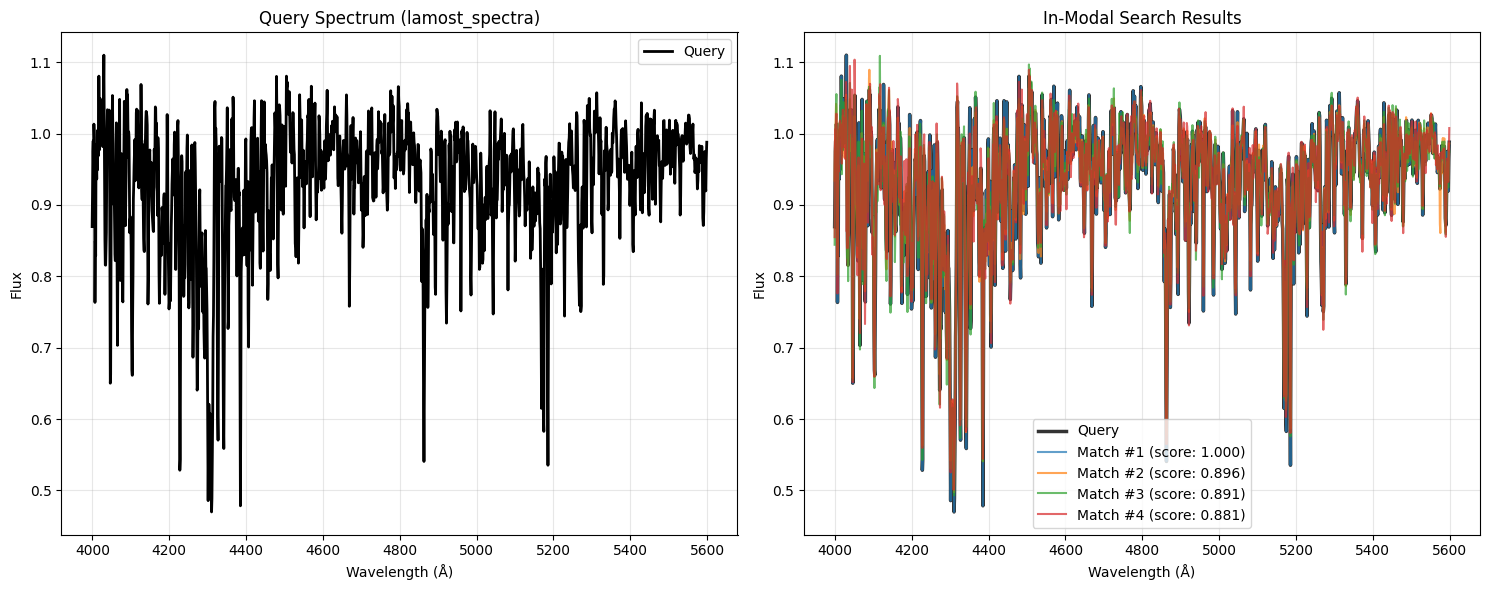

In [6]:
# Query using a spectrum from the test set (by index)
# The top match should be the query itself

!mkdir ./plots/

query_idx = 100  # Example index

# LAMOST in-modal search
results_lamost = retriever.find_similar_spectra(
    query_spectrum=query_idx,
    query_type='lamost_spectra',
    search_type='in_modal',
    top_k=4,
    exclude_self=False  # Include self to verify it's top match
)

print(f"Query Index: {query_idx}")
print(f"Top match index: {results_lamost['top_indices'][0]}")
print(f"Top match score: {results_lamost['top_scores'][0]:.4f}")
print(f"\nIs query the top match? {results_lamost['top_indices'][0] == query_idx}")
print(f"\nAll match indices: {results_lamost['top_indices']}")
print(f"All match scores: {results_lamost['top_scores']}")

# Plot results
retriever.plot_retrieval_results(
    results_lamost,
    save_path=f'./plots/lamost_in_modal_query_{query_idx}.png'
)

### In-Modal Retrieval - Gaia XP (Task 2)

Query Index: 250
Top match index: 250
Is query the top match? True


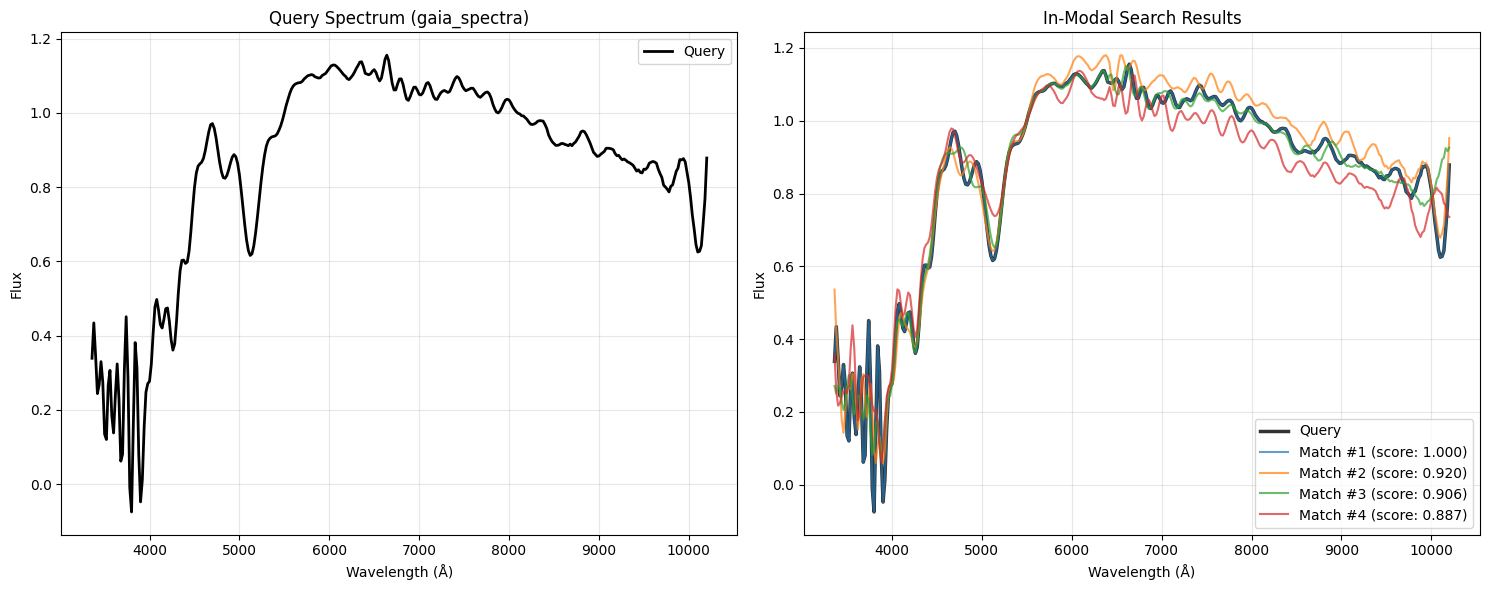

In [7]:
# Same for Gaia XP
query_idx = 250

results_gaia = retriever.find_similar_spectra(
    query_spectrum=query_idx,
    query_type='gaia_spectra',
    search_type='in_modal',
    top_k=4,
    exclude_self=False
)

print(f"Query Index: {query_idx}")
print(f"Top match index: {results_gaia['top_indices'][0]}")
print(f"Is query the top match? {results_gaia['top_indices'][0] == query_idx}")

retriever.plot_retrieval_results(results_gaia)

### External Spectrum In-Modal Retrieval (Task 3)

(3908,)
(3908,)
Top match indices: [52193 45613 14126 37870]
Top match scores: [0.74016154 0.699684   0.69483465 0.69120646]

Source IDs of matches:
  Match #1: 3342657945652088192
  Match #2: 1736598626601814784
  Match #3: 1498612878118499456
  Match #4: 615738228225346304
Saved plot to ./plots/external_lamost_in_modal.png


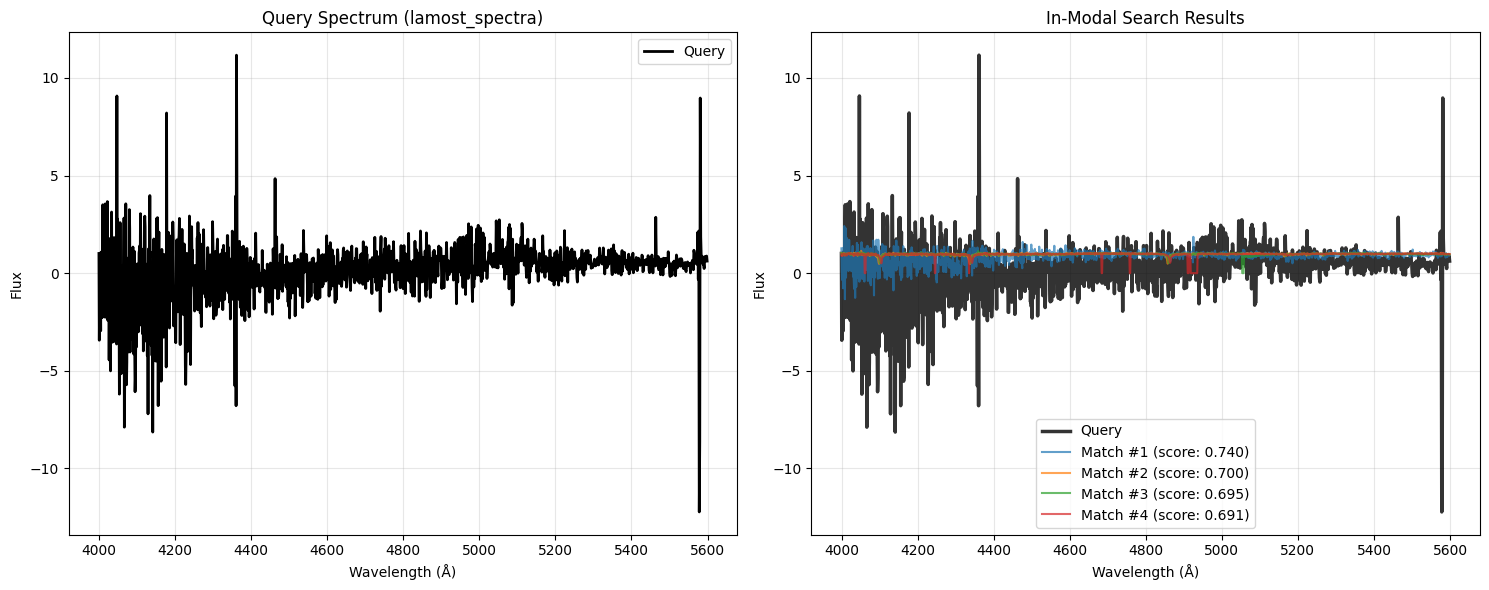

In [10]:
# Load an external LAMOST spectrum
wavelength, flux = load_spectrum_data('./test_data/lrs/sample4_txt.csv')
print (flux.shape)
#wavelength = wavelength.reshape(-1,1)
#flux = flux.reshape(-1,1)
print (flux.shape)

# Find similar spectra
results_external_lamost = retriever.find_similar_spectra(
    query_spectrum=(wavelength, flux),  # Pass as tuple
    query_type='lamost_spectra',
    search_type='in_modal',
    top_k=4
)

print(f"Top match indices: {results_external_lamost['top_indices']}")
print(f"Top match scores: {results_external_lamost['top_scores']}")
print(f"\nSource IDs of matches:")
for i, source_id in enumerate(results_external_lamost['source_ids']):
    print(f"  Match #{i+1}: {source_id}")

# Plot
retriever.plot_retrieval_results(
    results_external_lamost,
    save_path='./plots/external_lamost_in_modal.png'
)

### External Gaia XP Spectrum Retrieval (Task 3)

Top 4 matches found
Scores: [0.95241374 0.9082484  0.89569247 0.8944562 ]


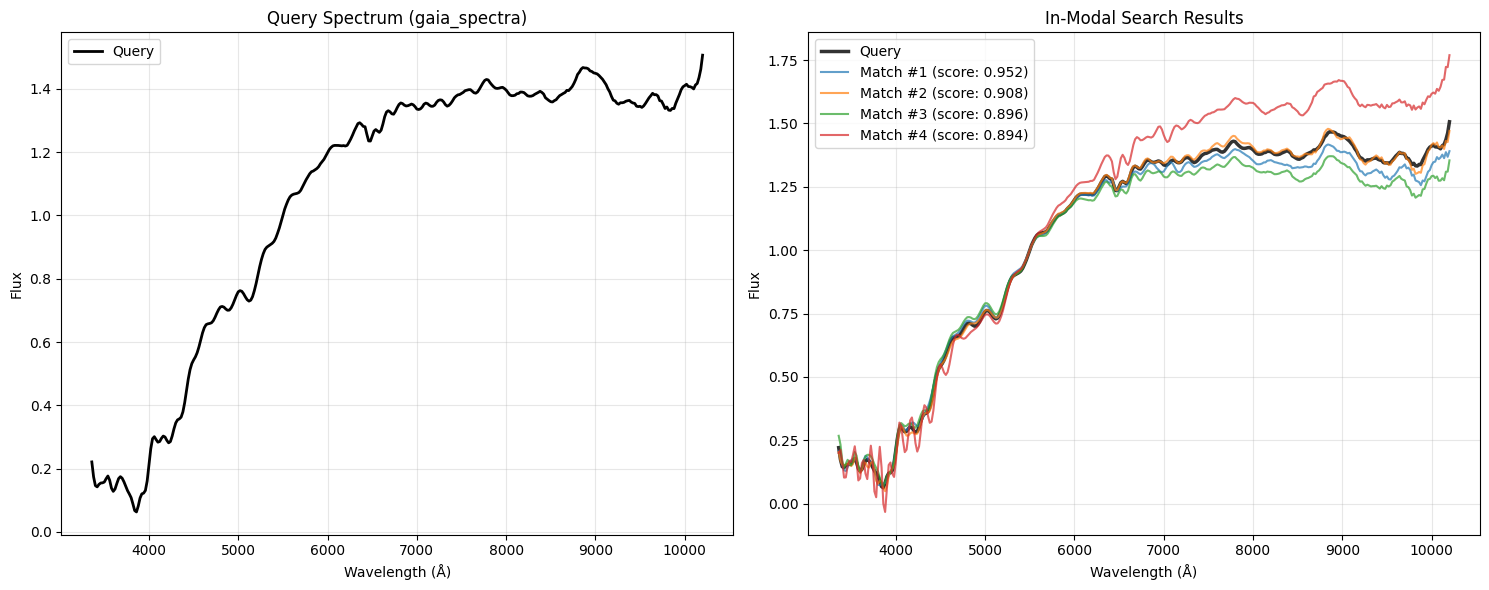

In [13]:
# Load external Gaia XP spectrum
wavelength_xp, flux_xp = load_spectrum_data_xp('./test_data/xp/sample4_txt_xp.csv')

results_external_gaia = retriever.find_similar_spectra(
    query_spectrum=(wavelength_xp, flux_xp),
    query_type='gaia_spectra',
    search_type='in_modal',
    top_k=4
)

print(f"Top {len(results_external_gaia['top_spectra'])} matches found")
print(f"Scores: {results_external_gaia['top_scores']}")

retriever.plot_retrieval_results(results_external_gaia)

### Cross-Modal Retrieval from Test Set (Task 4)

LAMOST Query Index: 114
Top Gaia match index: 114
Top match score: 0.8870

Expected paired index: 114
Is paired spectrum the top match? True
Saved plot to ./plots/lamost_to_gaia_cross_modal_query_114.png


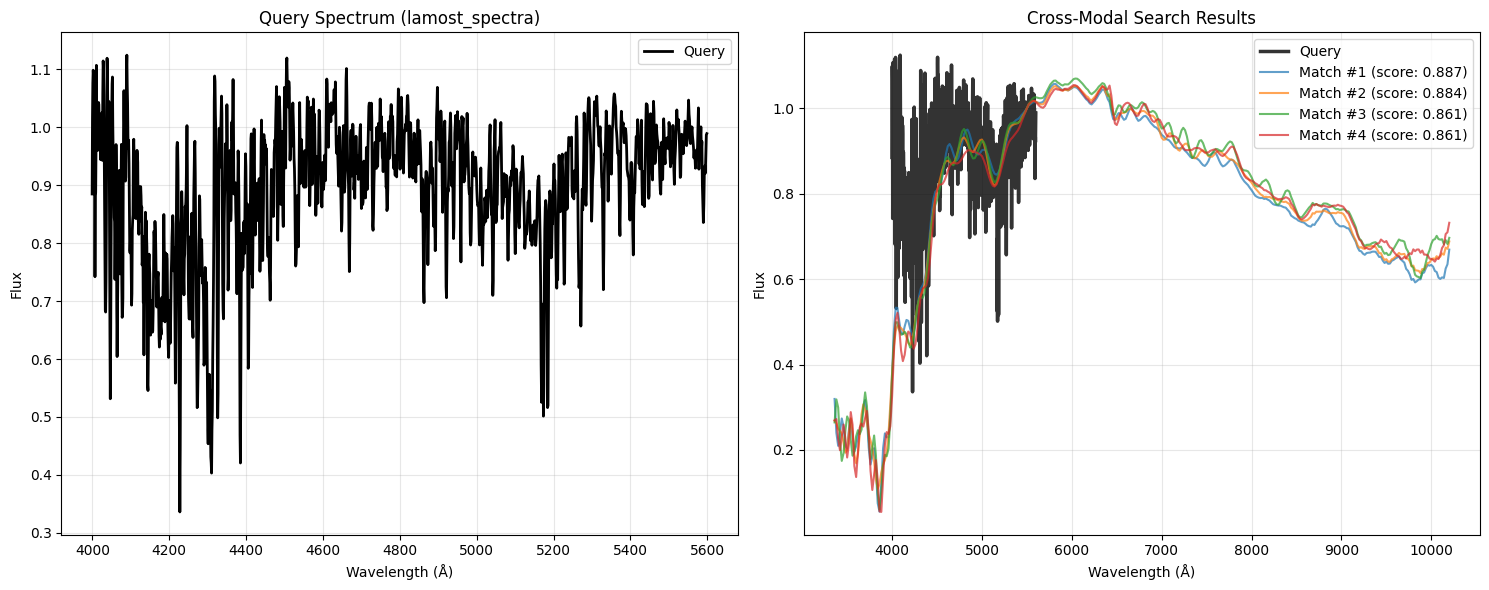

In [14]:
# LAMOST query -> Find similar Gaia XP spectra
query_idx = 114 #100

results_lamost_to_gaia = retriever.find_similar_spectra(
    query_spectrum=query_idx,
    query_type='lamost_spectra',
    search_type='cross_modal',
    top_k=4,
    exclude_self=False
)

print(f"LAMOST Query Index: {query_idx}")
print(f"Top Gaia match index: {results_lamost_to_gaia['top_indices'][0]}")
print(f"Top match score: {results_lamost_to_gaia['top_scores'][0]:.4f}")
print(f"\nExpected paired index: {query_idx}")
print(f"Is paired spectrum the top match? {results_lamost_to_gaia['top_indices'][0] == query_idx}")

retriever.plot_retrieval_results(
    results_lamost_to_gaia,
    save_path=f'./plots/lamost_to_gaia_cross_modal_query_{query_idx}.png'
)

### Cross-Modal Retrieval - Gaia to LAMOST (Task 4)

Gaia Query Index: 104
Top LAMOST match index: 11610
Is paired spectrum the top match? False


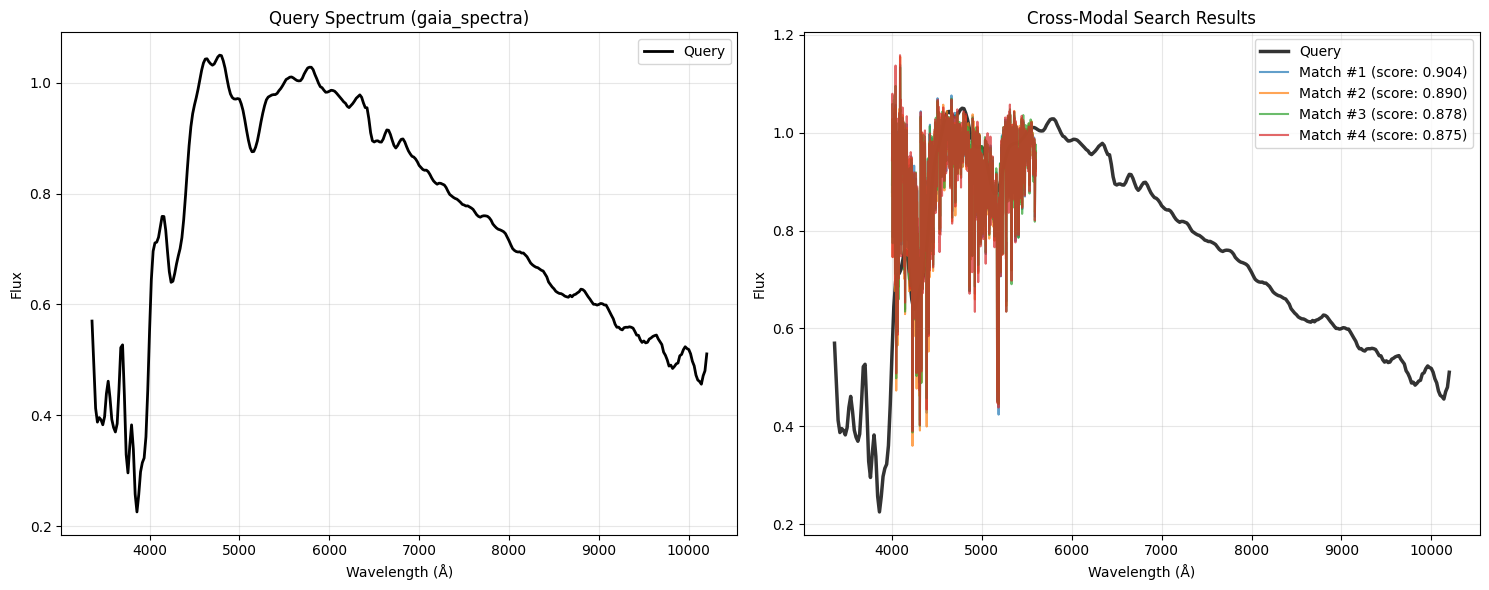

In [15]:
# Gaia query -> Find similar LAMOST spectra
#query_idx = 250
query_idx = 104

results_gaia_to_lamost = retriever.find_similar_spectra(
    query_spectrum=query_idx,
    query_type='gaia_spectra',
    search_type='cross_modal',
    top_k=4,
    exclude_self=False
)

print(f"Gaia Query Index: {query_idx}")
print(f"Top LAMOST match index: {results_gaia_to_lamost['top_indices'][0]}")
print(f"Is paired spectrum the top match? {results_gaia_to_lamost['top_indices'][0] == query_idx}")

retriever.plot_retrieval_results(results_gaia_to_lamost)

### External LAMOST LRS Cross-Modal Retrieval (Task 5)

Cross-modal retrieval: LAMOST → Gaia XP
Top 4 Gaia matches found
Scores: [0.5922396  0.5916445  0.58601004 0.58343524]
Saved plot to ./plots/external_lamost_to_gaia_cross.png


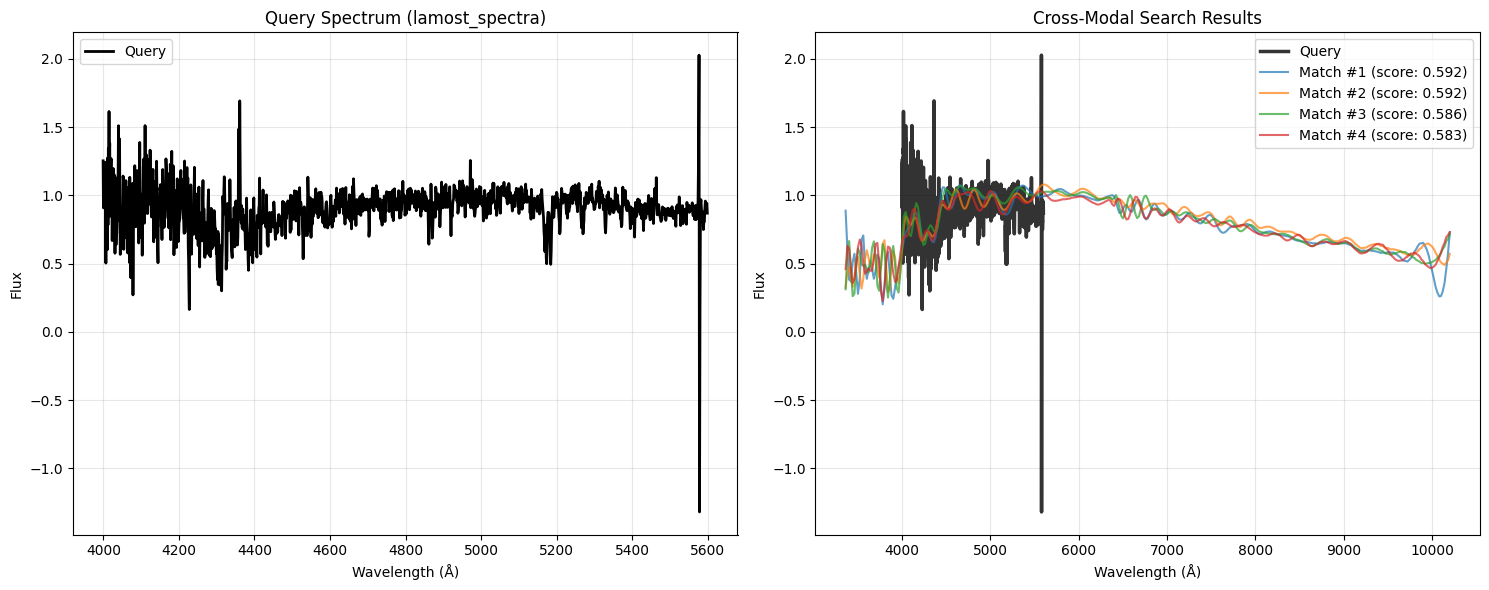

In [16]:
# Load external LAMOST spectrum
wavelength, flux = load_spectrum_data('./test_data/lrs/sample1_matrix.fits')

# Find similar Gaia XP spectra
results_external_cross = retriever.find_similar_spectra(
    query_spectrum=(wavelength, flux),
    query_type='lamost_spectra',
    search_type='cross_modal',
    top_k=4
)

print("Cross-modal retrieval: LAMOST → Gaia XP")
print(f"Top {len(results_external_cross['top_spectra'])} Gaia matches found")
print(f"Scores: {results_external_cross['top_scores']}")

retriever.plot_retrieval_results(
    results_external_cross,
    save_path='./plots/external_lamost_to_gaia_cross.png'
)

### External Gaia XP Cross-Modal Retrieval (Task 5)

Cross-modal retrieval: Gaia XP → LAMOST
Top match score: 0.8911


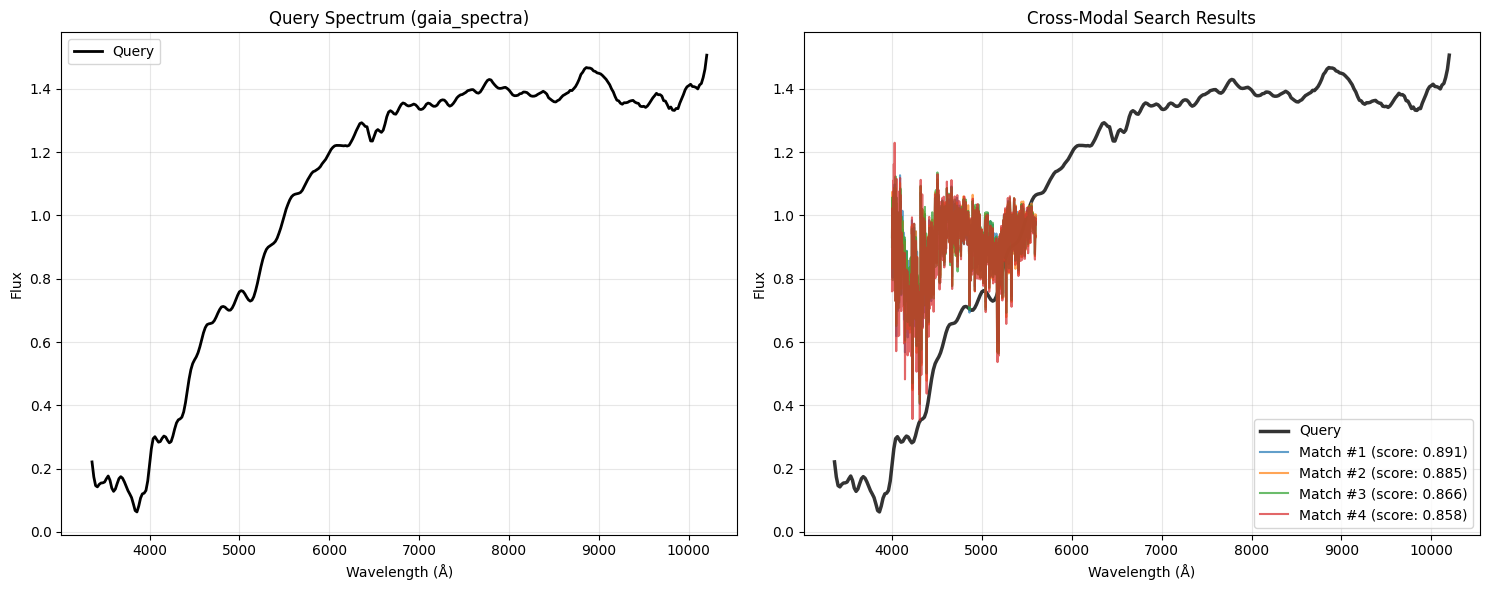

In [17]:
# Load external Gaia XP spectrum
wavelength_xp, flux_xp = load_spectrum_data_xp('./test_data/xp/sample4_txt_xp.csv')

# Find similar LAMOST spectra
results_gaia_cross = retriever.find_similar_spectra(
    query_spectrum=(wavelength_xp, flux_xp),
    query_type='gaia_spectra',
    search_type='cross_modal',
    top_k=4
)

print("Cross-modal retrieval: Gaia XP → LAMOST")
print(f"Top match score: {results_gaia_cross['top_scores'][0]:.4f}")

retriever.plot_retrieval_results(results_gaia_cross)

### Cross-Modal Prediction from Test Set (Task 6)

Query type: lamost_spectra
Predicted type: gaia_spectra
Has ground truth: True
Saved plot to ./plots/lamost_to_gaia_prediction_104.png


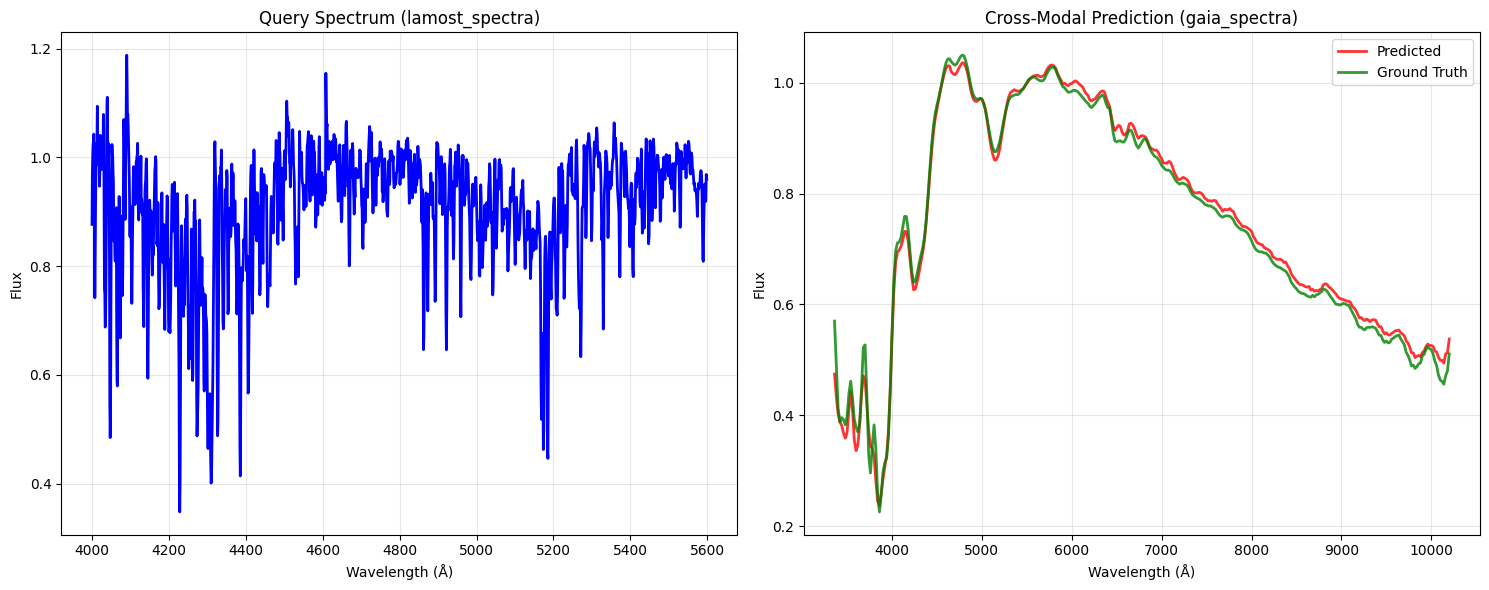

In [18]:
# Predict Gaia spectrum from LAMOST
query_idx = 104 #100

prediction_results = retriever.predict_cross_modal(
    query_spectrum=query_idx,
    query_type='lamost_spectra'
)

print(f"Query type: {prediction_results['query_type']}")
print(f"Predicted type: {prediction_results['predicted_type']}")
print(f"Has ground truth: {prediction_results['ground_truth'] is not None}")

# Plot prediction vs ground truth
retriever.plot_cross_modal_prediction(
    prediction_results,
    save_path=f'./plots/lamost_to_gaia_prediction_{query_idx}.png'
)

Query type: gaia_spectra
Predicted type: lamost_spectra
Has ground truth: True
Saved plot to ./plots/gaia_to_lamost_prediction_104.png


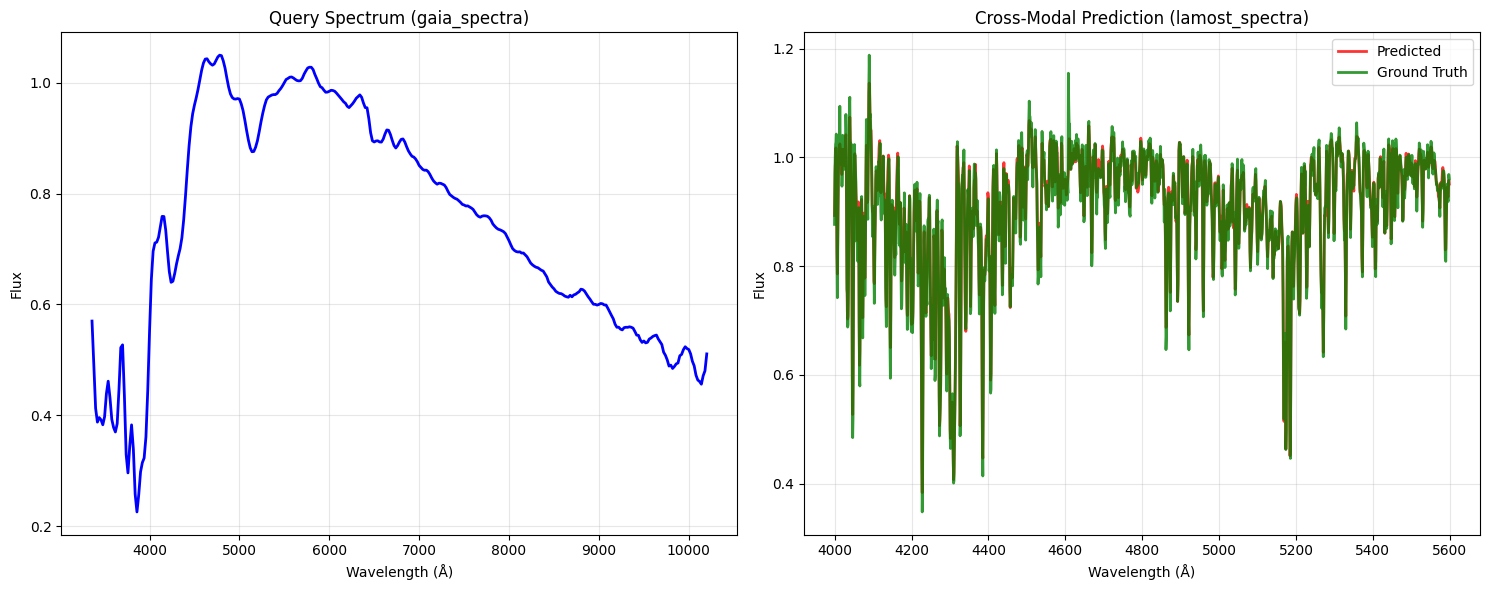

In [20]:
# Predict Gaia spectrum from LAMOST
query_idx = 104 #100

prediction_results = retriever.predict_cross_modal(
    query_spectrum=query_idx,
    query_type='gaia_spectra'
)

print(f"Query type: {prediction_results['query_type']}")
print(f"Predicted type: {prediction_results['predicted_type']}")
print(f"Has ground truth: {prediction_results['ground_truth'] is not None}")

# Plot prediction vs ground truth
retriever.plot_cross_modal_prediction(
    prediction_results,
    save_path=f'./plots/gaia_to_lamost_prediction_{query_idx}.png'
)

### Cross-Modal Prediction - External LAMOST (Task 6)

Predicting Gaia XP spectrum from external LAMOST spectrum
Predicted spectrum shape: (343,)
Saved plot to ./plots/external_lamost_to_gaia_prediction.png


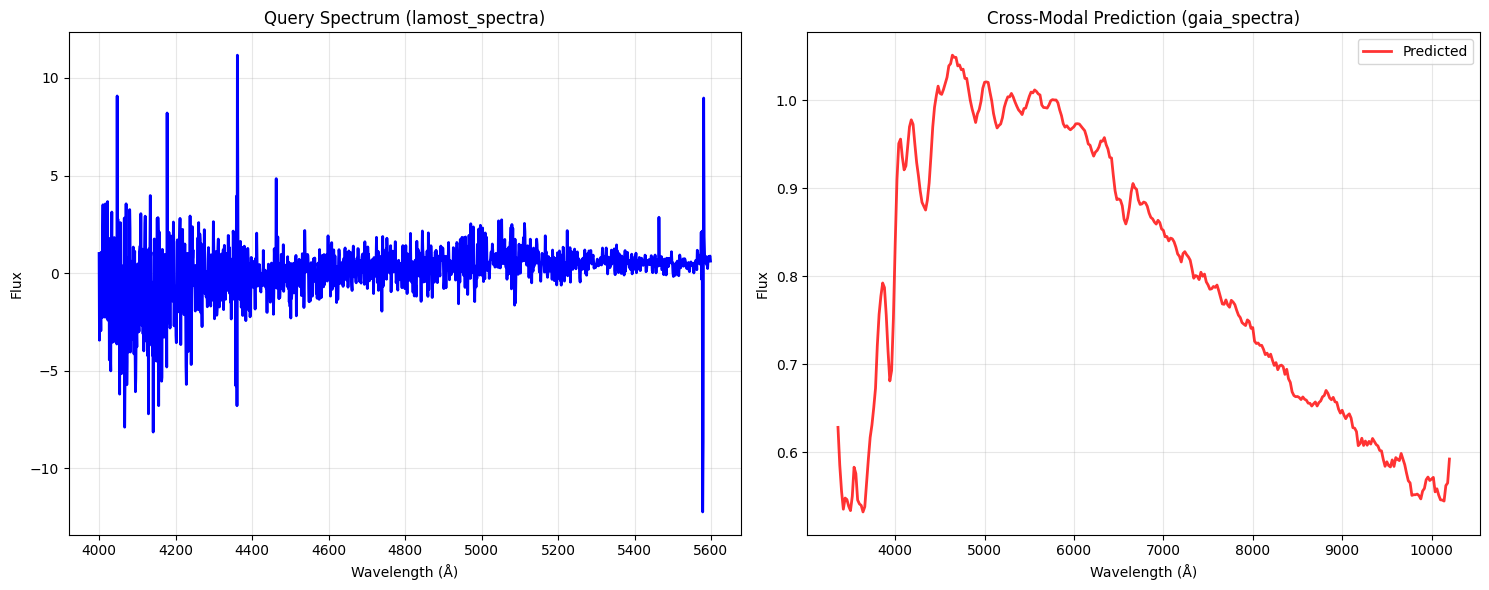

In [21]:
# Load external LAMOST spectrum
wavelength, flux = load_spectrum_data('./test_data/lrs/sample1_matrix.fits')
wavelength, flux = load_spectrum_data('./test_data/lrs/sample4_txt.csv')

# Predict corresponding Gaia XP spectrum
prediction_external = retriever.predict_cross_modal(
    query_spectrum=(wavelength, flux),
    query_type='lamost_spectra'
)

print("Predicting Gaia XP spectrum from external LAMOST spectrum")
print(f"Predicted spectrum shape: {prediction_external['predicted_spectrum'].shape}")

retriever.plot_cross_modal_prediction(
    prediction_external,
    save_path='./plots/external_lamost_to_gaia_prediction.png'
)

### Cross-Modal Prediction - External Gaia XP (Task 6)

Predicting LAMOST spectrum from external Gaia XP spectrum
Saved plot to ./plots/external_gaia_to_lamost_prediction.png


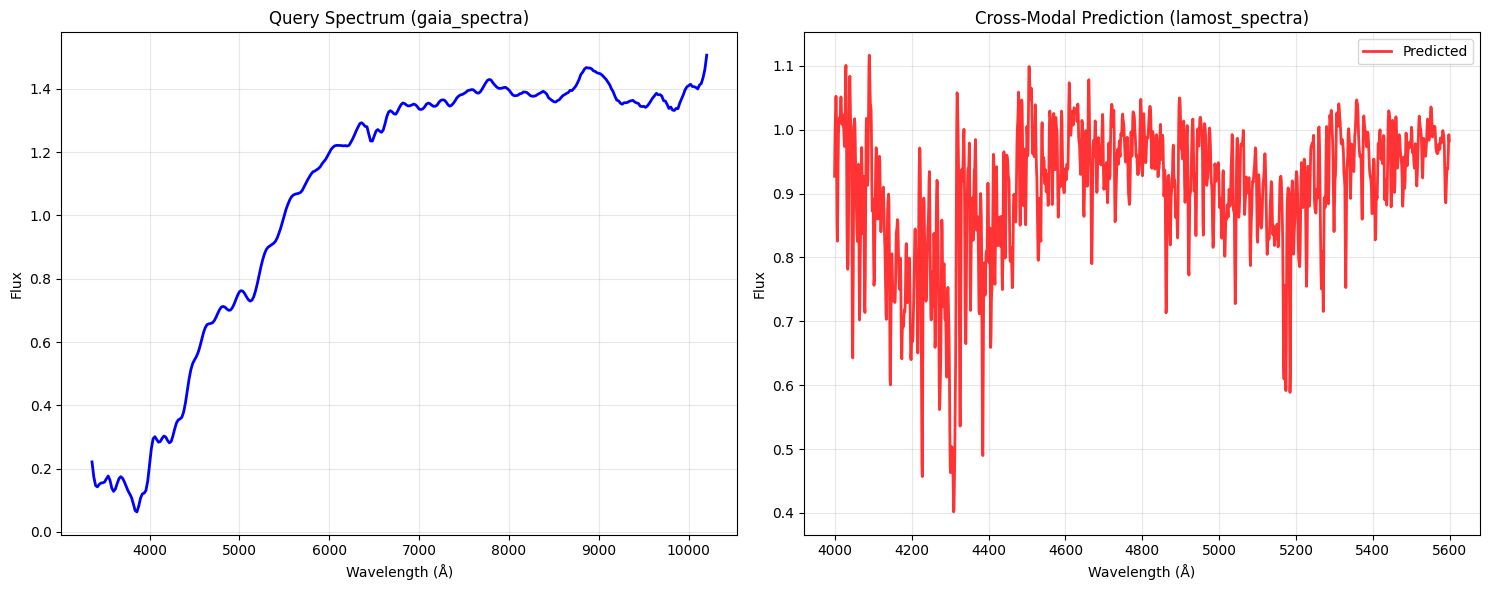

In [22]:
# Load external Gaia XP spectrum
wavelength_xp, flux_xp = load_spectrum_data_xp('./test_data/xp/sample4_txt_xp.csv')

# Predict corresponding LAMOST spectrum
prediction_gaia = retriever.predict_cross_modal(
    query_spectrum=(wavelength_xp, flux_xp),
    query_type='gaia_spectra'
)

print("Predicting LAMOST spectrum from external Gaia XP spectrum")

retriever.plot_cross_modal_prediction(
    prediction_gaia,
    save_path='./plots/external_gaia_to_lamost_prediction.png'
)

### Batch Processing Multiple Queries

In [23]:
# Process multiple queries at once
query_indices = [10, 50, 100, 250, 500]

results_batch = []
for idx in query_indices:
    result = retriever.find_similar_spectra(
        query_spectrum=idx,
        query_type='lamost_spectra',
        search_type='in_modal',
        top_k=4,
        exclude_self=False
    )
    results_batch.append(result)
    print(f"Query {idx}: Top match = {result['top_indices'][0]}, "
          f"Score = {result['top_scores'][0]:.4f}")

Query 10: Top match = 10, Score = 1.0000
Query 50: Top match = 50, Score = 1.0000
Query 100: Top match = 100, Score = 1.0000
Query 250: Top match = 250, Score = 1.0000
Query 500: Top match = 500, Score = 1.0000


### Compare In-Modal vs Cross-Modal Retrieval

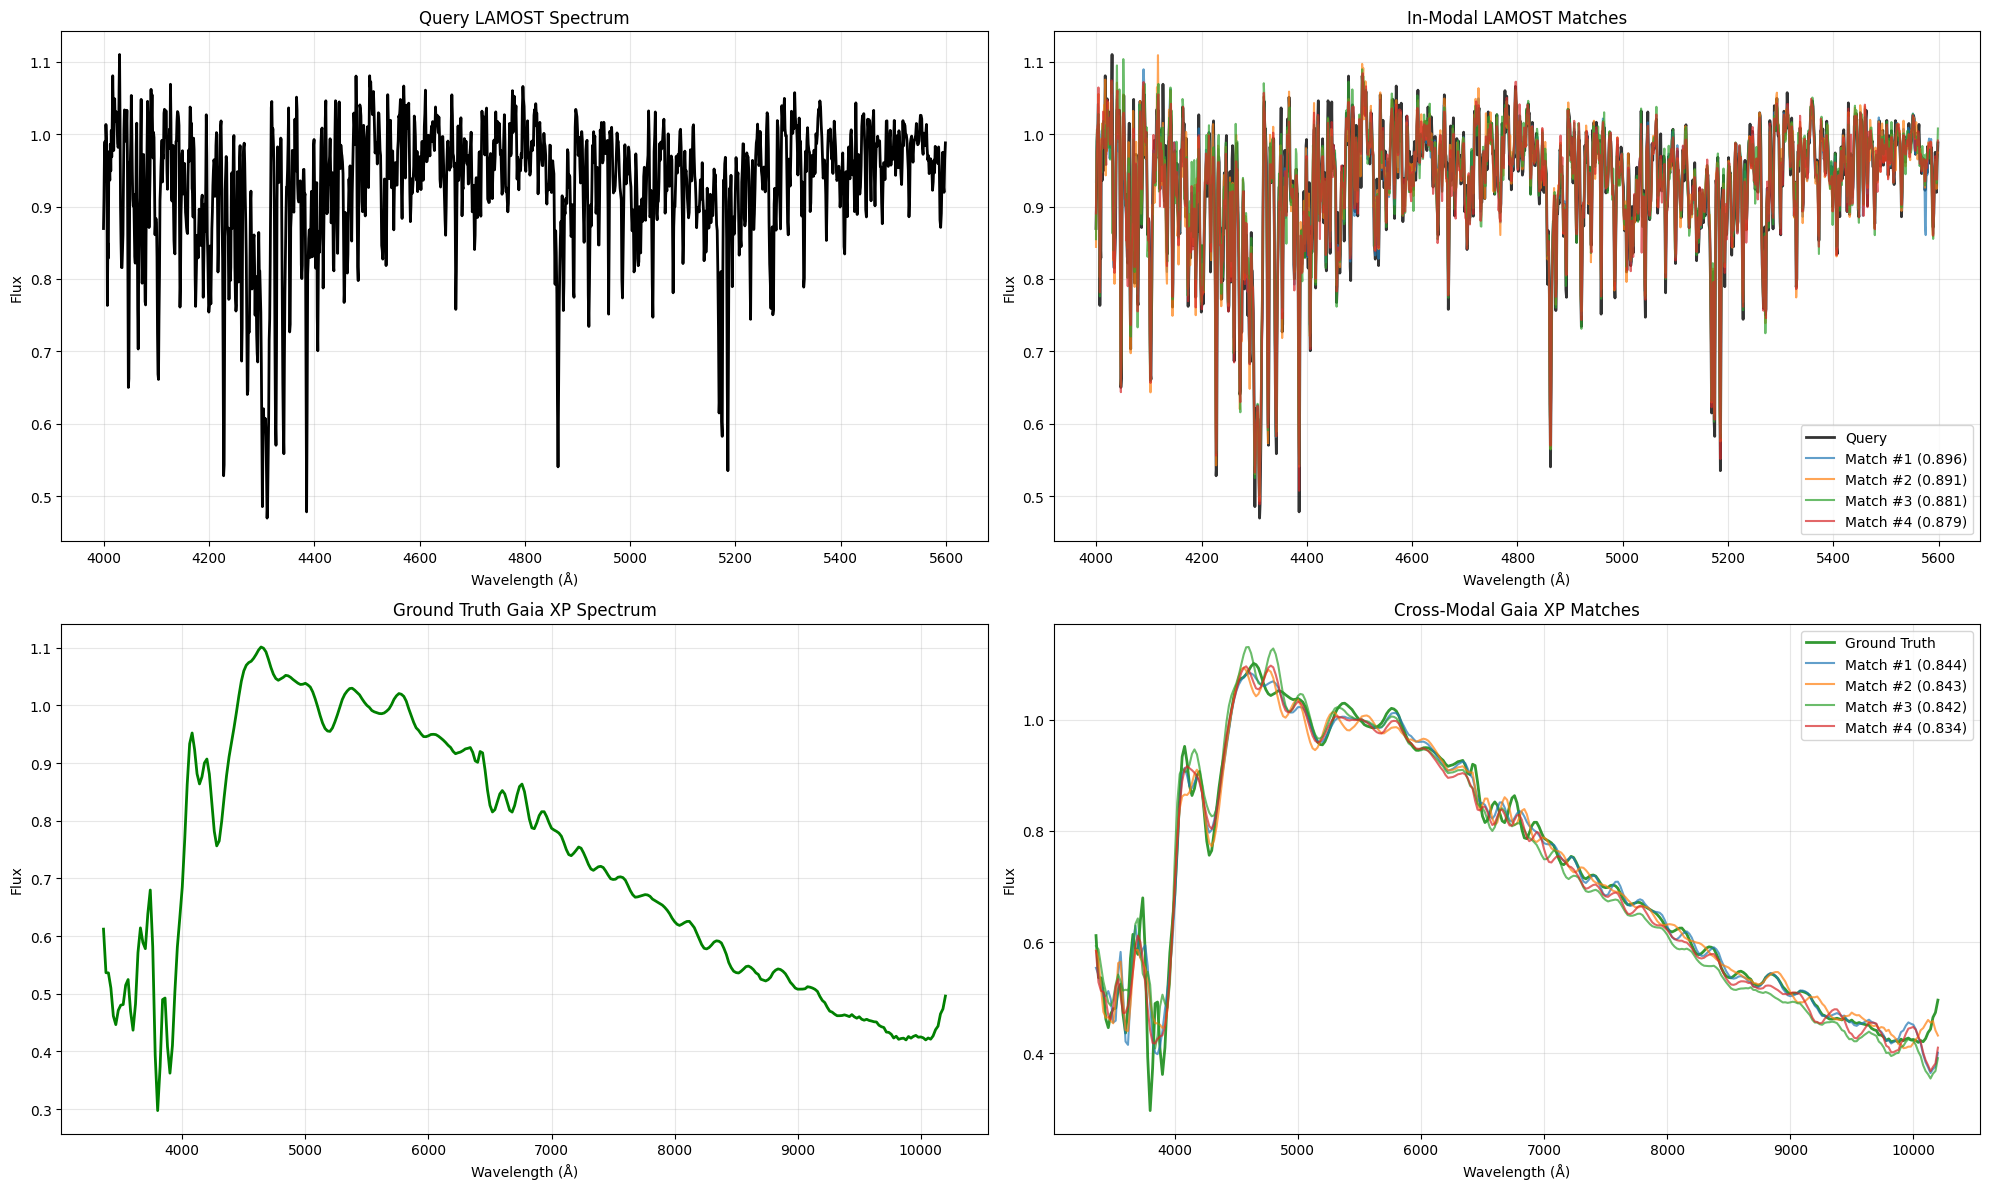

In [24]:
query_idx = 100

# In-modal
in_modal = retriever.find_similar_spectra(
    query_idx, 'lamost_spectra', 'in_modal', top_k=4, exclude_self=True
)

# Cross-modal
cross_modal = retriever.find_similar_spectra(
    query_idx, 'lamost_spectra', 'cross_modal', top_k=4
)

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# Query
axes[0, 0].plot(retriever.lamost_wavelengths, in_modal['query_spectrum'], 'k-', linewidth=2)
axes[0, 0].set_title('Query LAMOST Spectrum')
axes[0, 0].set_xlabel('Wavelength (Å)')
axes[0, 0].set_ylabel('Flux')
axes[0, 0].grid(True, alpha=0.3)

# In-modal matches
axes[0, 1].plot(retriever.lamost_wavelengths, in_modal['query_spectrum'], 
               'k-', linewidth=2, label='Query', alpha=0.8)
for i, (spec, score) in enumerate(zip(in_modal['top_spectra'], in_modal['top_scores'])):
    axes[0, 1].plot(retriever.lamost_wavelengths, spec, linewidth=1.5, alpha=0.7,
                   label=f'Match #{i+1} ({score:.3f})')
axes[0, 1].set_title('In-Modal LAMOST Matches')
axes[0, 1].set_xlabel('Wavelength (Å)')
axes[0, 1].set_ylabel('Flux')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Ground truth Gaia
axes[1, 0].plot(retriever.gaia_wavelengths, retriever.gaia_spectra[query_idx], 
               'g-', linewidth=2)
axes[1, 0].set_title('Ground Truth Gaia XP Spectrum')
axes[1, 0].set_xlabel('Wavelength (Å)')
axes[1, 0].set_ylabel('Flux')
axes[1, 0].grid(True, alpha=0.3)

# Cross-modal matches
axes[1, 1].plot(retriever.gaia_wavelengths, retriever.gaia_spectra[query_idx],
               'g-', linewidth=2, label='Ground Truth', alpha=0.8)
for i, (spec, score) in enumerate(zip(cross_modal['top_spectra'], cross_modal['top_scores'])):
    axes[1, 1].plot(retriever.gaia_wavelengths, spec, linewidth=1.5, alpha=0.7,
                   label=f'Match #{i+1} ({score:.3f})')
axes[1, 1].set_title('Cross-Modal Gaia XP Matches')
axes[1, 1].set_xlabel('Wavelength (Å)')
axes[1, 1].set_ylabel('Flux')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./plots/in_modal_vs_cross_modal_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### Statistics and Analysis

[ 5223 37348  2361 73979  8230 18965 50340 32438 45025 21210 26139 34990
 14430 17549 22845 61222 48246 25797 64711 77028 40507 73961 57025 55086
 30704 17987 46718 64177 15875  8466 33721 15722 73759 24164 61002 77941
 57430 64813 77829 66834   378 56909  6651 72777 74019 56854  8777 61363
 16050 64002 36376 49795  9008 19803 44423 43230 56501 63071 42700 53436
 57318  8569  7751 44744 68996  9945  6762 69652 53699  1406 70575 37376
 79665 60152 70816 51008 73891 22361 20277  6468 58553 53399 75123 33718
 77423 69984 45301  1217 73872 45353 81900 80026 76528 80784 53422 20796
 54831 20652 72984  5453]
In-Modal Retrieval:
  Top-1 Accuracy: 100.0%
  Mean Score: 1.0000
  Std Score: 0.0000

Cross-Modal Retrieval:
  Top-1 Accuracy: 11.0%
  Mean Score: 0.8698
  Std Score: 0.0430


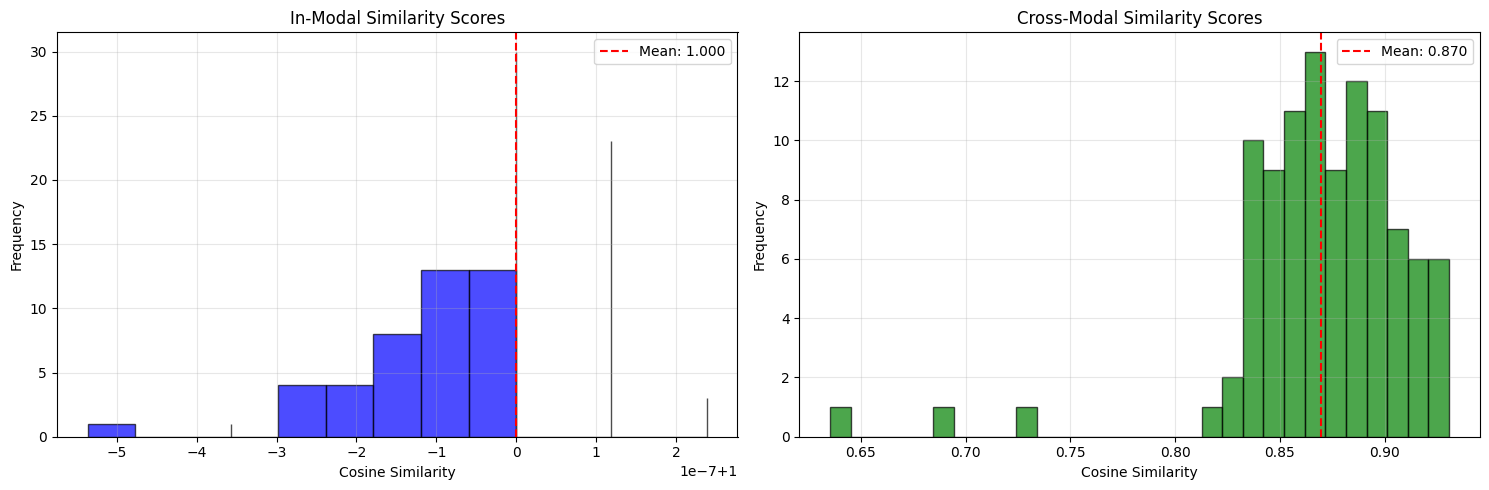

In [25]:
# Analyze retrieval performance across test set
import pandas as pd

# Sample random queries
np.random.seed(42)
sample_indices = np.random.choice(len(retriever.source_ids), 100, replace=False)

print (sample_indices)

stats = {
    'in_modal_top1_correct': 0,
    'cross_modal_top1_correct': 0,
    'in_modal_scores': [],
    'cross_modal_scores': []
}

for idx in sample_indices:
    idx = int(idx)
    # In-modal
    in_modal = retriever.find_similar_spectra(
        idx, 'lamost_spectra', 'in_modal', top_k=1, exclude_self=False
    )
    if in_modal['top_indices'][0] == idx:
        stats['in_modal_top1_correct'] += 1
    stats['in_modal_scores'].append(in_modal['top_scores'][0])
    
    # Cross-modal
    cross_modal = retriever.find_similar_spectra(
        idx, 'lamost_spectra', 'cross_modal', top_k=1
    )
    if cross_modal['top_indices'][0] == idx:
        stats['cross_modal_top1_correct'] += 1
    stats['cross_modal_scores'].append(cross_modal['top_scores'][0])

print(f"In-Modal Retrieval:")
print(f"  Top-1 Accuracy: {stats['in_modal_top1_correct']/100*100:.1f}%")
print(f"  Mean Score: {np.mean(stats['in_modal_scores']):.4f}")
print(f"  Std Score: {np.std(stats['in_modal_scores']):.4f}")

print(f"\nCross-Modal Retrieval:")
print(f"  Top-1 Accuracy: {stats['cross_modal_top1_correct']/100*100:.1f}%")
print(f"  Mean Score: {np.mean(stats['cross_modal_scores']):.4f}")
print(f"  Std Score: {np.std(stats['cross_modal_scores']):.4f}")

# Plot score distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(stats['in_modal_scores'], bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_title('In-Modal Similarity Scores')
axes[0].set_xlabel('Cosine Similarity')
axes[0].set_ylabel('Frequency')
axes[0].axvline(np.mean(stats['in_modal_scores']), color='red', linestyle='--', 
               label=f'Mean: {np.mean(stats["in_modal_scores"]):.3f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(stats['cross_modal_scores'], bins=30, alpha=0.7, color='green', edgecolor='black')
axes[1].set_title('Cross-Modal Similarity Scores')
axes[1].set_xlabel('Cosine Similarity')
axes[1].set_ylabel('Frequency')
axes[1].axvline(np.mean(stats['cross_modal_scores']), color='red', linestyle='--',
               label=f'Mean: {np.mean(stats["cross_modal_scores"]):.3f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./plots/score_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

### **Comprehensive Spectral Analysis Card**

This analysis card provides a unified, end-to-end summary of the stellar information contained in the input spectrum. For a given **query spectrum** (either **LAMOST LRS** or **Gaia XP**), the card presents:

---

#### **1. Stellar Parameter Estimation**

If a stellar-parameter predictor is supplied, the card lists all inferred physical parameters.

* **For LAMOST LRS**, the predicted parameters include:

  * **Chemical abundances (12):**
    [α/Fe], [C/Fe], [N/Fe], [Mg/Fe], [O/Fe], [Al/Fe], [Si/Fe], [Ca/Fe], [Ti/Fe], [Mn/Fe], [Ni/Fe], [Cr/Fe]
  * **Asteroseismic parameters:**
    Δν, ν_max, mass, radius, age, ΔΠ₁
  * **Atmospheric parameters:**
    T_eff, log g, [Fe/H]
  * **Other parameters:**
    RV, E(BP–RP)

* **For Gaia XP**, the predicted parameters include:

  * **Chemical abundances:** [α/Fe], [C/Fe], [N/Fe]
  * **Atmospheric parameters:** T_eff, log g, [Fe/H]
  * **Extinction:** E(BP–RP)

---

#### **2. In-Modal Retrieval**

The top-1 nearest-neighbour spectrum in the **same survey**
(LAMOST → LAMOST or Gaia XP → Gaia XP) is shown:

* Similarity score
* Matched spectrum overplotted with the query
* Matched source ID (if available)

---

#### **3. Cross-Modal Retrieval**

The top-1 nearest-neighbour from the **other survey** is displayed
(e.g., Gaia XP → LAMOST LRS or LAMOST LRS → Gaia XP),
allowing direct comparison of corresponding spectral features across instruments.

---

#### **4. Cross-Modal Prediction**

Using the SpecCLIP cross-decoder, the model generates the **predicted spectrum in the opposite modality** (e.g., LAMOST → predicted Gaia XP).
This demonstrates the model’s ability to translate spectral information across different surveys.

---

Together, these panels summarize the model’s capabilities in **stellar parameter inference**, **in-modal and cross-modal retrieval**, and **cross-modal spectral prediction**, offering a complete diagnostic for interpreting the input spectrum.

### Generate Analysis Card for LAMOST Spectrum in the test sample (possibly a young star)

mkdir: cannot create directory ‘./cards/’: File exists
Initializing LAMOST LRS predictor...
This predictor supports:
  - Chemical abundances (12 elements)
  - Asteroseismic parameters
  - Radial velocity
  - Atmospheric parameters
  - Reddening
Using device: cuda
Loading models...
Total trainable parameters: 42,846,129
Total trainable parameters: 42,846,129
Models loaded successfully!
Generating comprehensive analysis card...
  - Predicting stellar parameters...


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

...

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  - Finding in-modal match...
  - Finding cross-modal match...
  - Generating cross-modal prediction...
  - Creating visualization...
✓ Saved analysis card to ./cards/lamost_analysis_card.png


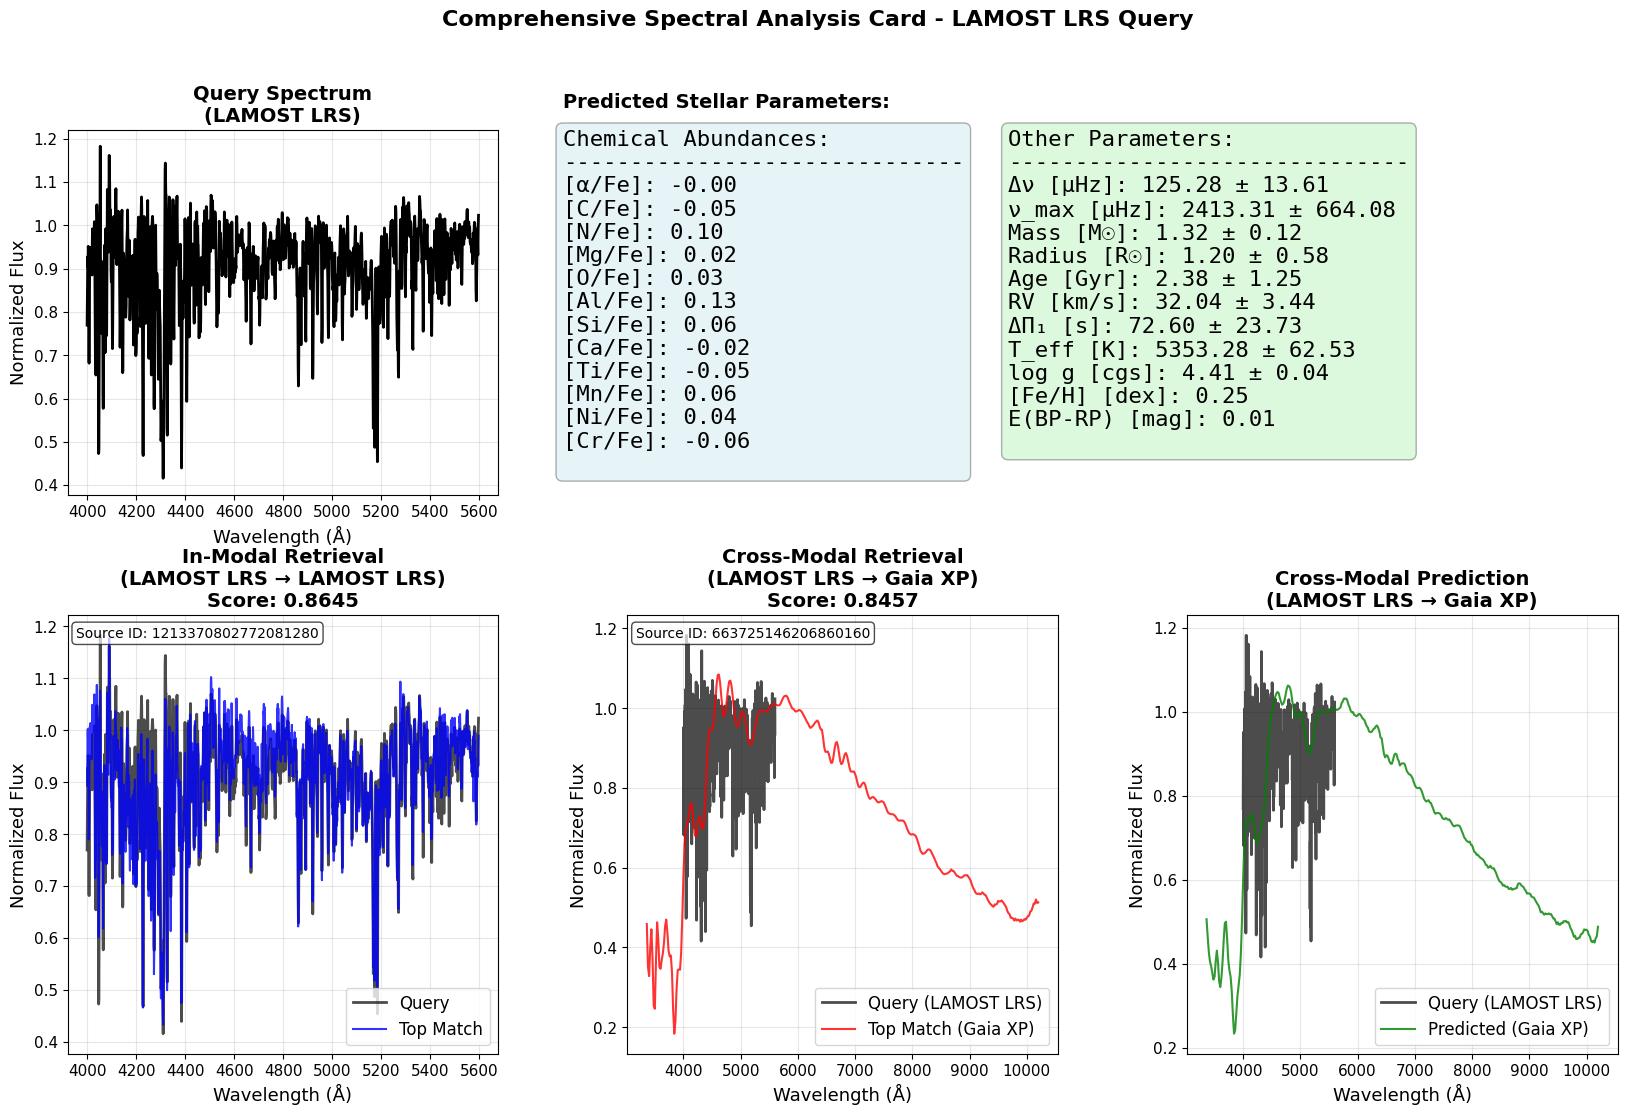

✓ Analysis card generation complete!

Stellar Parameters:


,Parameter,Prediction,Error,Method
0,[α/Fe],-0.00,NaN,MLP
1,[C/Fe],-0.05,NaN,MLP
2,[N/Fe],0.10,NaN,MLP
3,[Mg/Fe],0.02,NaN,MLP
4,[O/Fe],0.03,NaN,MLP
5,[Al/Fe],0.13,NaN,MLP
6,[Si/Fe],0.06,NaN,MLP
7,[Ca/Fe],-0.02,NaN,MLP
8,[Ti/Fe],-0.05,NaN,MLP
9,[Mn/Fe],0.06,NaN,MLP



In-modal match score: 0.8645
Cross-modal match score: 0.8457


In [38]:
import h5py
h5_data_path = '/home/idies/workspace/Temporary/xzhao/scratch/pretrained_models/test_data/gaia_lamost_test_only.h5'
with h5py.File(h5_data_path, 'r') as f:
    source_ids = np.array(f['test/source_ids'][:])
    #gaia_spectra = np.array(f['test/gaia_spectra'][:])
    lamost_spectra = np.array(f['test/lamost_spectra'][:])

w_start = 3.602
w_end = w_start + 1e-4 * 1461
new_log_wave = np.linspace(w_start, w_end, 1462)

wavelength = 10 ** new_log_wave
flux = lamost_spectra[86][...,0] # 72

from stellar_params_unified import UnifiedStellarParameterPredictor

!mkdir ./cards/

# Initialize stellar parameter predictor
stellar_predictor = UnifiedStellarParameterPredictor('LAMOST_LRS', lrs_config=lrs_config)

# Generate comprehensive analysis card
card_results = retriever.generate_analysis_card(
    query_spectrum=(wavelength, flux),
    query_type='lamost_spectra',
    stellar_predictor=stellar_predictor,
    save_path='./cards/lamost_analysis_card.png',
    simple_header=False
)

# Access individual results
print("\nStellar Parameters:")
display(card_results['stellar_parameters'])

print(f"\nIn-modal match score: {card_results['in_modal_match']['score']:.4f}")
print(f"Cross-modal match score: {card_results['cross_modal_match']['score']:.4f}")

### Generate Analysis Card for External LAMOST Spectrum (possibly an old star)

mkdir: cannot create directory ‘./cards/’: File exists
Initializing LAMOST LRS predictor...
This predictor supports:
  - Chemical abundances (12 elements)
  - Asteroseismic parameters
  - Radial velocity
  - Atmospheric parameters
  - Reddening
Using device: cuda
Loading models...
Total trainable parameters: 42,846,129
Total trainable parameters: 42,846,129
Models loaded successfully!
Generating comprehensive analysis card...
  - Predicting stellar parameters...


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

...

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  - Finding in-modal match...
  - Finding cross-modal match...
  - Generating cross-modal prediction...
  - Creating visualization...
✓ Saved analysis card to ./cards/lamost_analysis_card.png


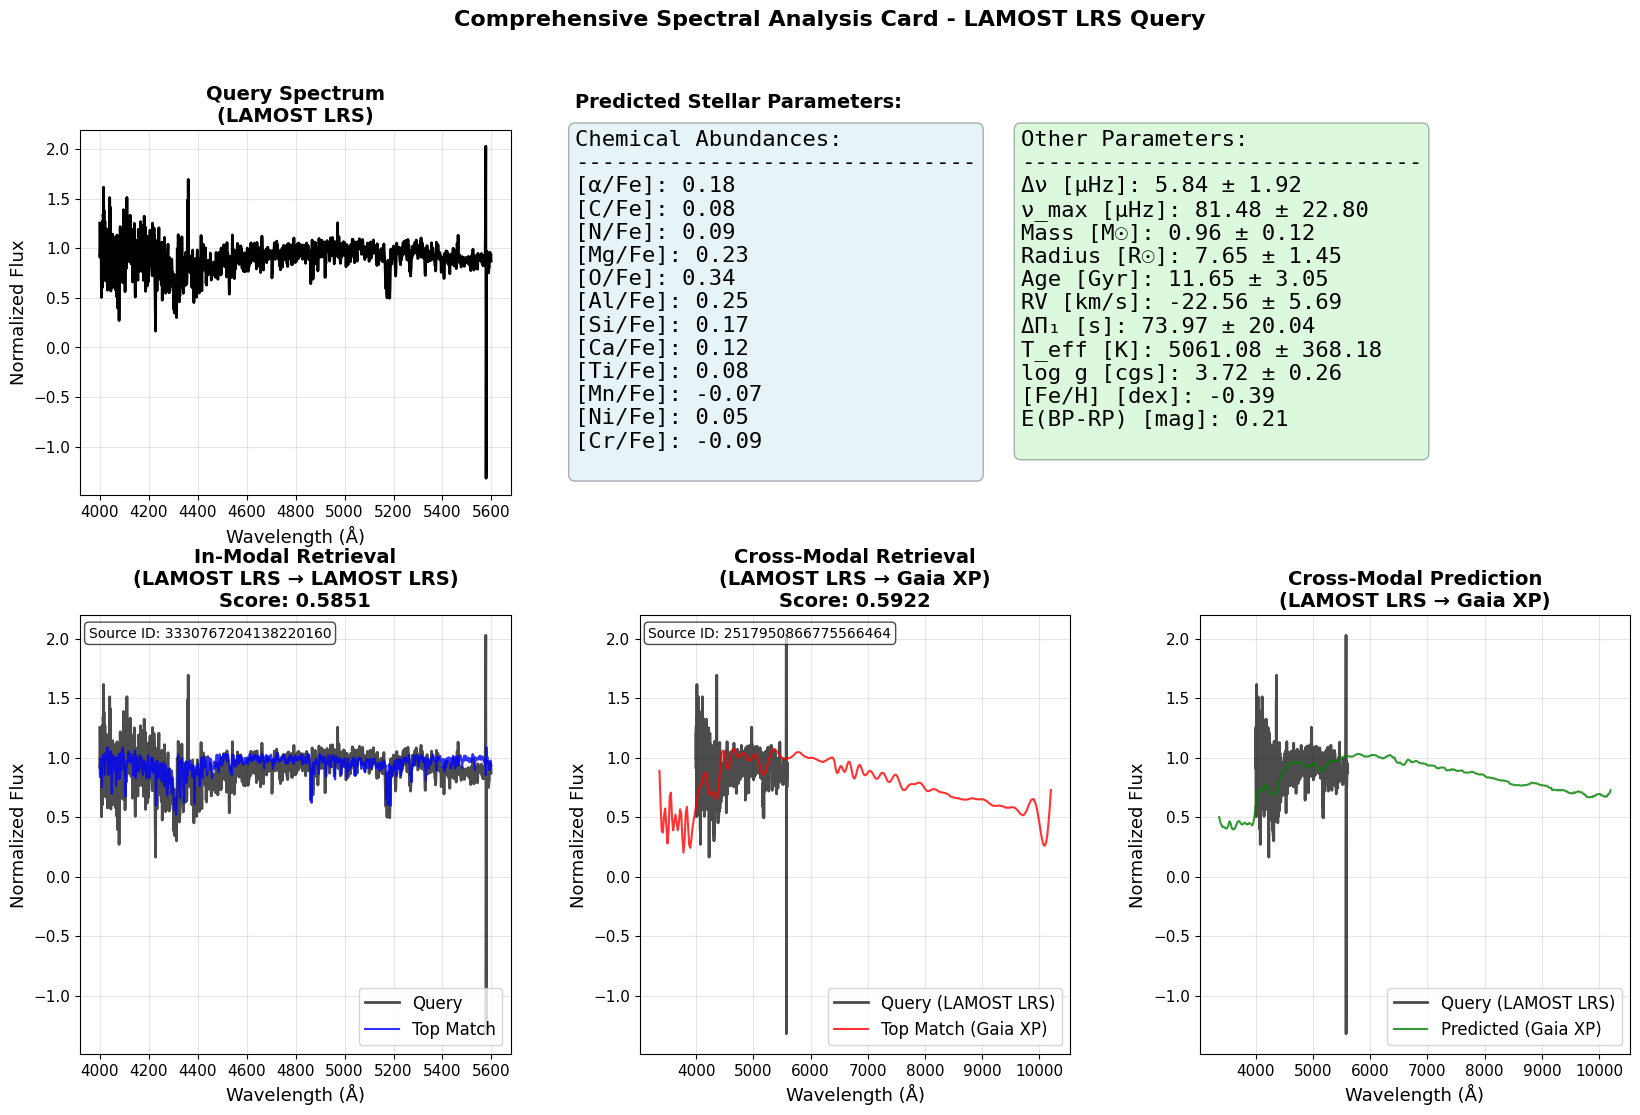

✓ Analysis card generation complete!

Stellar Parameters:


,Parameter,Prediction,Error,Method
0,[α/Fe],0.18,NaN,MLP
1,[C/Fe],0.08,NaN,MLP
2,[N/Fe],0.09,NaN,MLP
3,[Mg/Fe],0.23,NaN,MLP
4,[O/Fe],0.34,NaN,MLP
5,[Al/Fe],0.25,NaN,MLP
6,[Si/Fe],0.17,NaN,MLP
7,[Ca/Fe],0.12,NaN,MLP
8,[Ti/Fe],0.08,NaN,MLP
9,[Mn/Fe],-0.07,NaN,MLP



In-modal match score: 0.5851
Cross-modal match score: 0.5922



In-modal match score: 0.5851
Cross-modal match score: 0.5922


In [70]:
from stellar_params_unified import UnifiedStellarParameterPredictor

!mkdir ./cards/

# Initialize stellar parameter predictor
stellar_predictor = UnifiedStellarParameterPredictor('LAMOST_LRS', lrs_config=lrs_config)

# Load external LAMOST spectrum
wavelength, flux = load_spectrum_data('./test_data/lrs/sample1_matrix.fits')
#wavelength, flux = load_spectrum_data('./test_data/lrs/sample4_txt.csv')
#wavelength, flux = load_spectrum_data('./test_data/lrs/spec-55859-F5902_sp04-056.fits.gz')
#wavelength, flux = load_spectrum_data('./test_data/lrs/spec-57101-HD152912N162344B01_sp01-026.fits.gz')
#wavelength, flux = load_spectrum_data('./test_data/lrs/spec-55859-F5902_sp03-019.fits.gz')
#wavelength, flux = load_spectrum_data('./test_data/lrs/spec-55859-F5902_sp02-084.fits.gz')

# Generate comprehensive analysis card
card_results = retriever.generate_analysis_card(
    query_spectrum=(wavelength, flux),
    query_type='lamost_spectra',
    stellar_predictor=stellar_predictor,
    save_path='./cards/lamost_analysis_card.png',
    simple_header=False
)

# Access individual results
print("\nStellar Parameters:")
display(card_results['stellar_parameters'])

print(f"\nIn-modal match score: {card_results['in_modal_match']['score']:.4f}")
print(f"Cross-modal match score: {card_results['cross_modal_match']['score']:.4f}")

In [47]:
from astropy.io import fits
file_path = './test_data/lrs/spec-55859-F5902_sp01-005.fits.gz'
with fits.open(file_path) as hdul:
    print (hdul.info())

Filename: ./test_data/lrs/spec-55859-F5902_sp01-005.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  Flux          1 PrimaryHDU     127   (3908, 5)   float32   
None


### Generate Analysis Card for Gaia XP Spectrum in the test sample

Initializing Gaia XP predictor...
This predictor supports:
  - Alpha element abundance
  - Carbon and Nitrogen abundances
  - Atmospheric parameters
  - Reddening
Using device: cuda
Loading models...
Total trainable parameters: 42,846,129
Total trainable parameters: 42,846,129
Total trainable parameters: 42,846,129
Models loaded successfully!
Generating comprehensive analysis card...
  - Predicting stellar parameters...


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  - Finding in-modal match...
  - Finding cross-modal match...
  - Generating cross-modal prediction...
  - Creating visualization...
✓ Saved analysis card to ./cards/gaia_xp_analysis_card.png


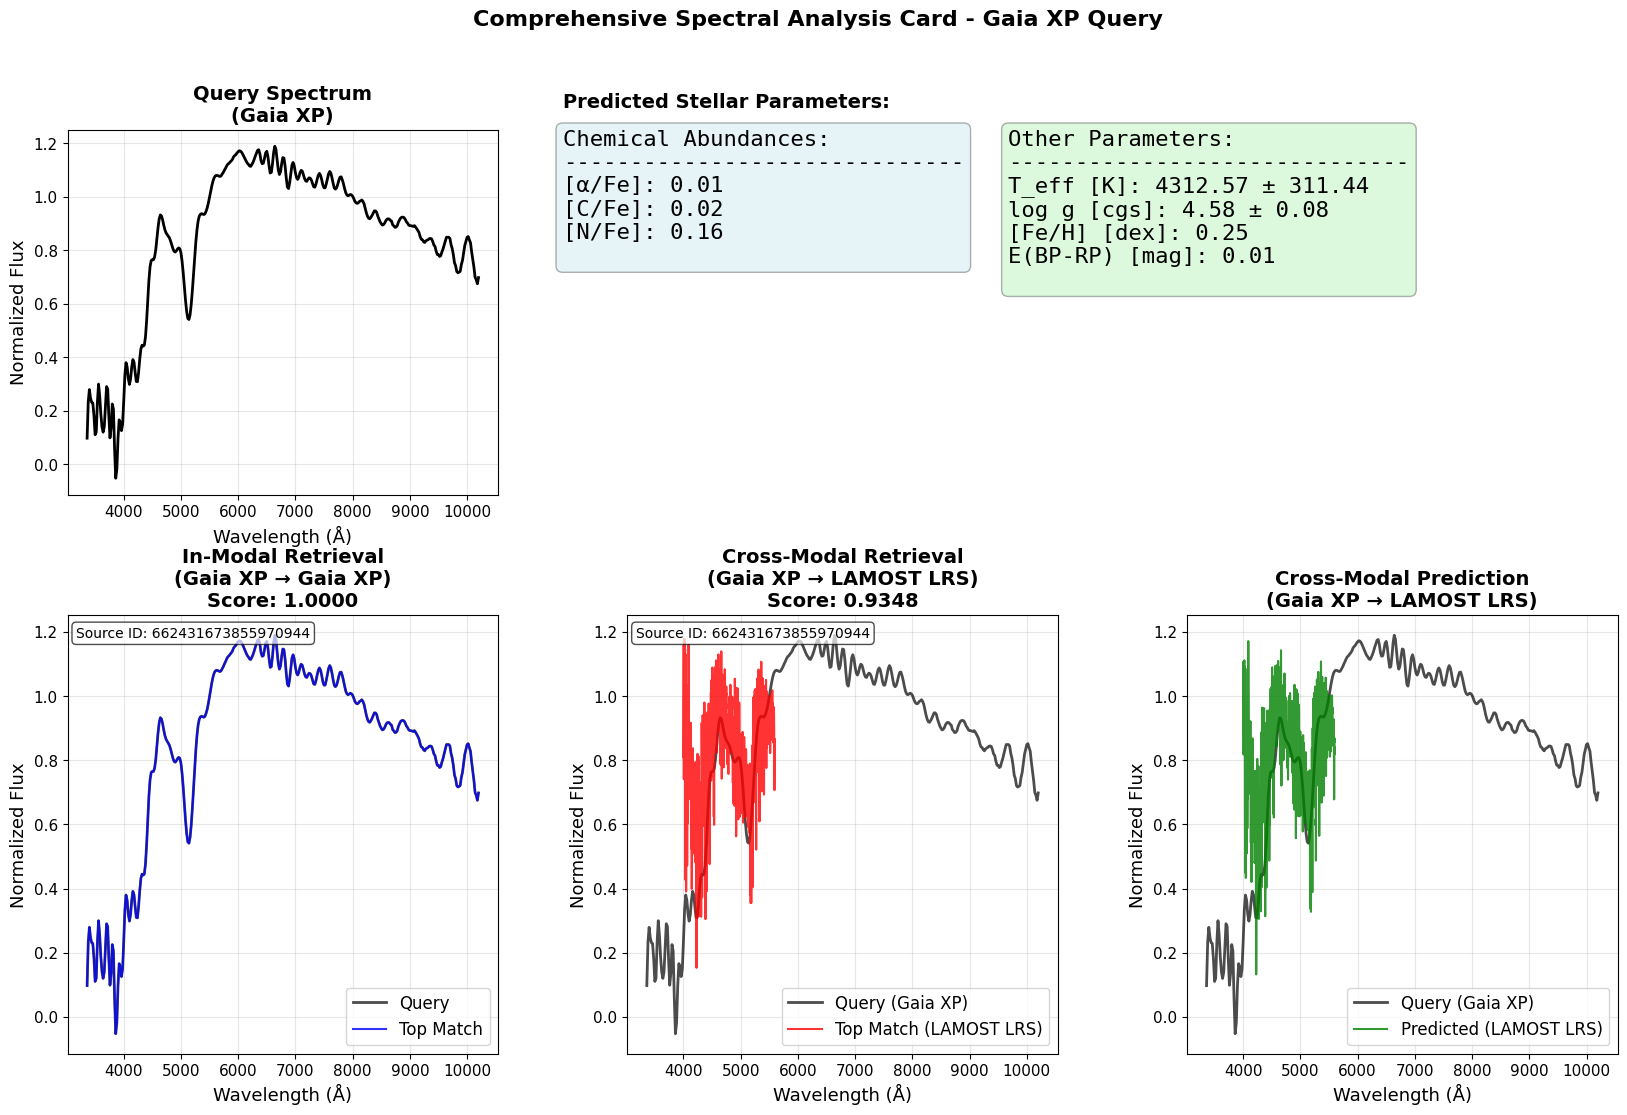

✓ Analysis card generation complete!


In [16]:
import h5py
h5_data_path = '/home/idies/workspace/Temporary/xzhao/scratch/pretrained_models/test_data/gaia_lamost_test_only.h5'
with h5py.File(h5_data_path, 'r') as f:
    source_ids = np.array(f['test/source_ids'][:])
    gaia_spectra = np.array(f['test/gaia_spectra'][:])
#lamost_spectra = np.array(f['test/lamost_spectra'][:])

from stellar_params_unified import UnifiedStellarParameterPredictor

# Initialize Gaia XP predictor
stellar_predictor_xp = UnifiedStellarParameterPredictor('Gaia_XP', xp_config=xp_config)

# Load external Gaia XP spectrum
wavelength_xp = np.arange(336, 1021, 2) 
flux_xp = gaia_spectra[72][...,0]


# Generate card
card_results_xp = retriever.generate_analysis_card(
    query_spectrum=(wavelength_xp, flux_xp),
    query_type='gaia_spectra',
    stellar_predictor=stellar_predictor_xp,
    save_path='./cards/gaia_xp_analysis_card.png',
    simple_header=False
)

### Generate Analysis Card for External Gaia XP Spectrum

Initializing Gaia XP predictor...
This predictor supports:
  - Alpha element abundance
  - Carbon and Nitrogen abundances
  - Atmospheric parameters
  - Reddening
Using device: cuda
Loading models...
Total trainable parameters: 42,846,129
Total trainable parameters: 42,846,129
Total trainable parameters: 42,846,129
Models loaded successfully!
Generating comprehensive analysis card...
  - Predicting stellar parameters...


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  - Finding in-modal match...
  - Finding cross-modal match...
  - Generating cross-modal prediction...
  - Creating visualization...
✓ Saved analysis card to ./cards/gaia_xp_analysis_card.png


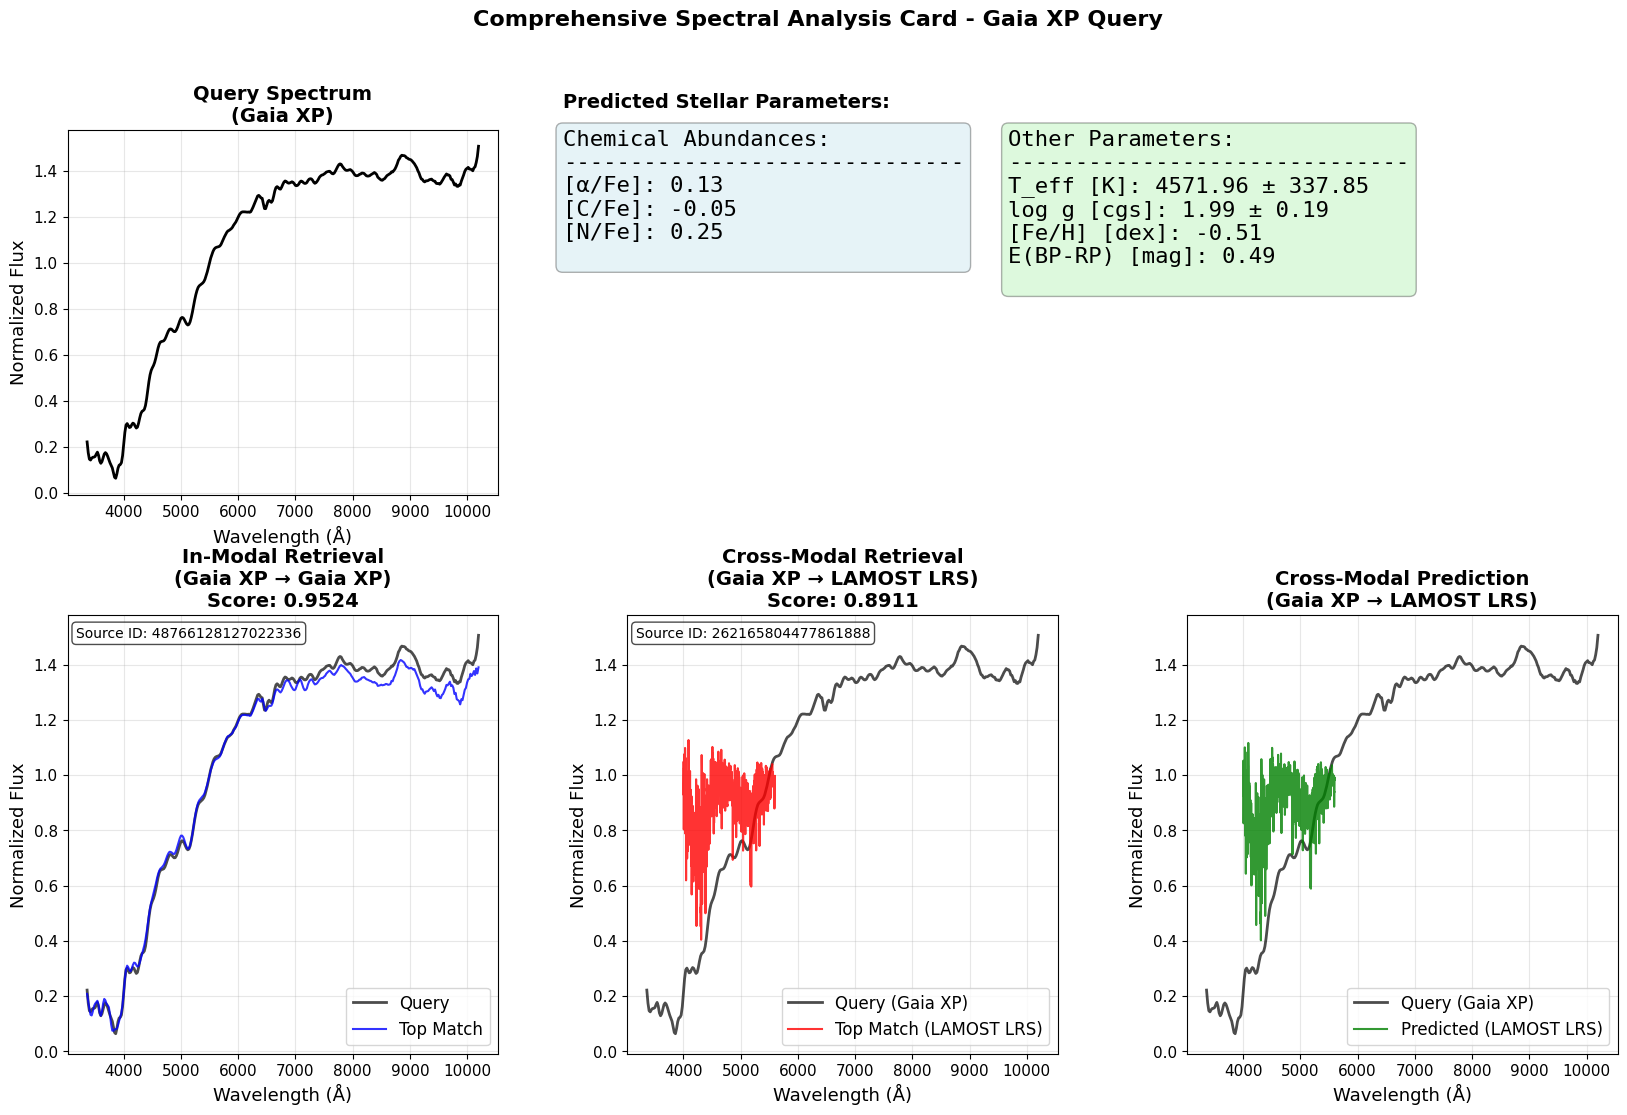

✓ Analysis card generation complete!


In [69]:
from stellar_params_unified import UnifiedStellarParameterPredictor

# Initialize Gaia XP predictor
stellar_predictor_xp = UnifiedStellarParameterPredictor('Gaia_XP', xp_config=xp_config)

# Load external Gaia XP spectrum
wavelength_xp, flux_xp = load_spectrum_data_xp('./test_data/xp/sample4_txt_xp.csv')

# Generate card
card_results_xp = retriever.generate_analysis_card(
    query_spectrum=(wavelength_xp, flux_xp),
    query_type='gaia_spectra',
    stellar_predictor=stellar_predictor_xp,
    save_path='./cards/gaia_xp_analysis_card.png',
    simple_header=False
)

## ✅ Summary

In this demo, you:

- Loaded the pretrained **SpecCLIP** model toether with the downstream-task models 
- Predicted stellar parameters from a Gaia XP/LAMOST-like spectrum  
- Learned how to retrieve similar spectra and predict cross-modal spectra prediction

For more details, check out the [GitHub repo](https://github.com/Xiaosheng-Zhao/SpecCLIP)
and the [paper](https://arxiv.org/abs/2507.01939).